# Task 1: Dataset Characterization

In [1]:
import random
import numpy as np
import torch
from transformers import set_seed

def set_reproducibility(seed=42):
    """
    Sets the seed for all relevant libraries to ensure 
    consistent results across different runs.
    """
    # 1. Base Python random module
    random.seed(seed)
    
    # 2. NumPy library for numerical operations
    np.random.seed(seed)
    
    # 3. PyTorch library (CPU and all GPUs)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    # 4. Hugging Face Transformers utility
    # This covers model weight initialization and data sampling
    set_seed(seed)
    
    # 5. CUDNN backend settings
    # Ensures that the GPU uses deterministic algorithms
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Global seed set to: {seed}")

# Execute the function at the beginning of your notebook
set_reproducibility(42)

/home/hanabi/miniconda3/envs/torch_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Global seed set to: 42


In [2]:
#load data from json files
import pandas as pd
INPUT_PATH = "datasets"
train_df = pd.read_json(f"{INPUT_PATH}/train.json")
test_df = pd.read_json(f"{INPUT_PATH}/test.json")
print(f"Number of training samples: {len(train_df)}")
print(f"Number of testing samples: {len(test_df)}")

Number of training samples: 251
Number of testing samples: 108


## Explore the labels: How many different tags do you have? How are they distributed (i.e., how many bash words are assigned per tag)? Plot a barplot to show the distribution of tags (both for Train and Test – 2 bars x tag)

--- Train Dataset Distribution ---
                 Tag  Count  Percentage
0          Discovery   6009       52.37
1          Execution   3239       28.23
2        Persistence   1133        9.87
3             Impact    312        2.72
4    Defense Evasion    309        2.69
5  Not Malicious Yet    264        2.30
6              Other    209        1.82

--- Test Dataset Distribution ---
                 Tag  Count  Percentage
0          Discovery   3307       53.36
1          Execution   1568       25.30
2        Persistence    683       11.02
3    Defense Evasion    218        3.52
4  Not Malicious Yet    212        3.42
5             Impact    133        2.15
6              Other     76        1.23

Success: The plot has been saved as 'tag_distribution.pdf'.


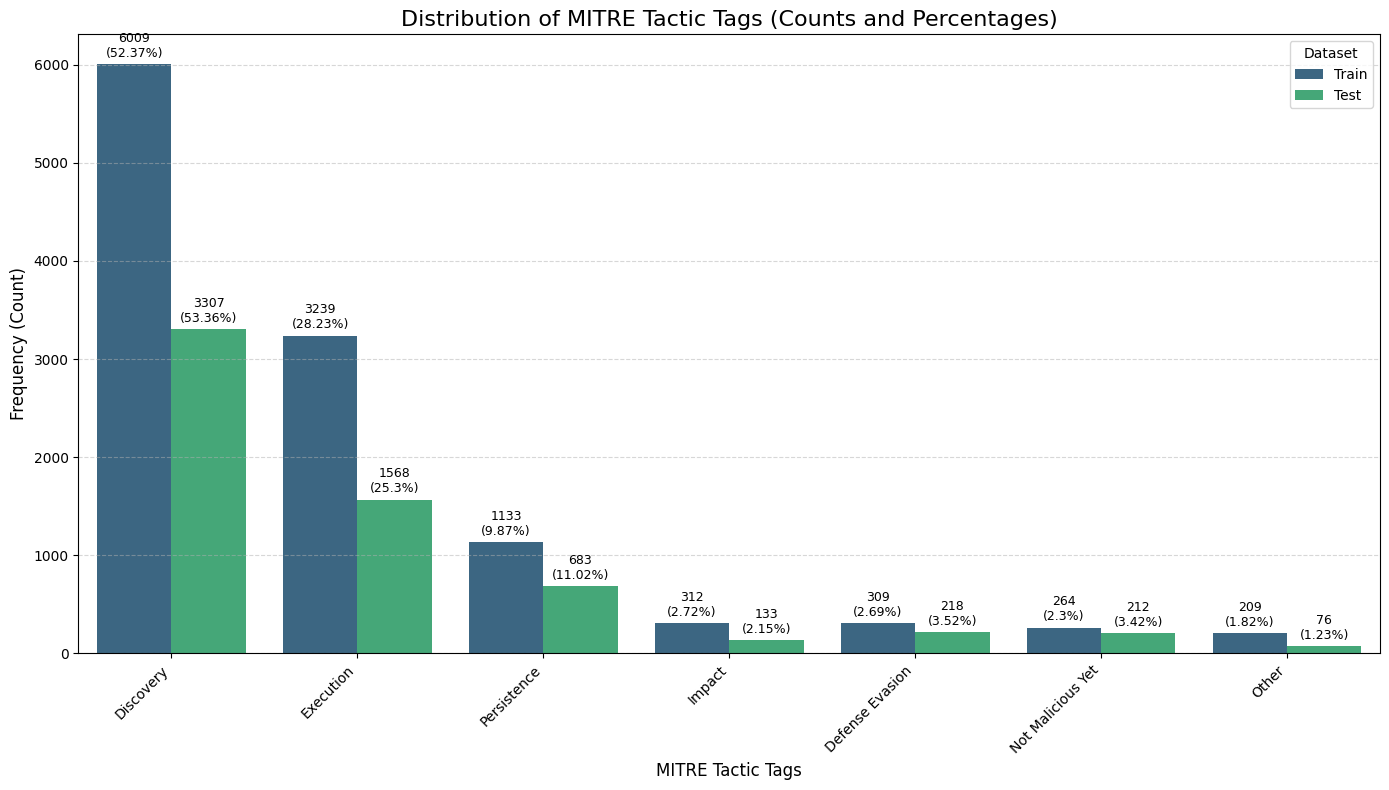

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Data Processing and Percentage Calculation
def get_distribution_data(df, name):
    """
    Explodes the label list, counts occurrences, 
    and calculates the percentage for each tag.
    """
    # Explode the list-like column and count values
    counts = df['label'].explode().value_counts().reset_index()
    counts.columns = ['Tag', 'Count']
    counts['Dataset'] = name
    
    # Calculate Percentage (Tag count / Total occurrences in this dataset)
    total_tags = counts['Count'].sum()
    counts['Percentage'] = (counts['Count'] / total_tags * 100).round(2)
    return counts

# Generate distribution dataframes
train_counts = get_distribution_data(train_df, 'Train')
test_counts = get_distribution_data(test_df, 'Test')

# Combine dataframes for visualization
plot_data = pd.concat([train_counts, test_counts])

# 2. Print Detailed Statistics to Console
print("--- Train Dataset Distribution ---")
print(train_counts[['Tag', 'Count', 'Percentage']])
print("\n--- Test Dataset Distribution ---")
print(test_counts[['Tag', 'Count', 'Percentage']])

# 3. Visualization Setup
plt.figure(figsize=(14, 8))
# Create grouped bar plot
ax = sns.barplot(data=plot_data, x='Tag', y='Count', hue='Dataset', palette='viridis')

# 4. Add Custom Labels (Count & Percentage) atop each bar
# We iterate through each dataset group (hue) to align labels correctly
for i, dataset_name in enumerate(['Train', 'Test']):
    subset = plot_data[plot_data['Dataset'] == dataset_name]
    
    # Get the order of tags currently displayed on the X-axis
    x_axis_order = [t.get_text() for t in ax.get_xticklabels()]
    
    # Construct labels in the exact order of the X-axis
    display_labels = []
    for tag in x_axis_order:
        row = subset[subset['Tag'] == tag]
        if not row.empty:
            count = row['Count'].values[0]
            perc = row['Percentage'].values[0]
            display_labels.append(f'{count}\n({perc}%)')
        else:
            # Add empty string if the tag doesn't exist in this dataset
            display_labels.append('')
            
    # Apply labels to the respective bar container
    ax.bar_label(ax.containers[i], labels=display_labels, padding=3, fontsize=9)

# 5. Styling and Aesthetics
plt.title('Distribution of MITRE Tactic Tags (Counts and Percentages)', fontsize=16)
plt.xlabel('MITRE Tactic Tags', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# 6. Export to PDF
# Saving as PDF preserves vector quality for documents/LaTeX
output_filename = 'tag_distribution.pdf'
plt.savefig(output_filename, format='pdf')

print(f"\nSuccess: The plot has been saved as '{output_filename}'.")
# plt.show() # Uncomment to preview the plot locally

## explore a single bash command – ‘echo’: how many different tags are assigned? How many times per tag?

In [4]:
from collections import Counter
import pandas as pd

def analyze_specific_word(df, target_word='echo'):
    word_labels = []
    for _, row in df.iterrows():
        tokens = row['session'].split()
        labels = row['label']
        # 确保 tokens 和 labels 长度一致
        for word, label in zip(tokens, labels):
            if word == target_word:
                word_labels.append(label)
    return Counter(word_labels)

# 分别对训练集和测试集执行统计
echo_train_stats = analyze_specific_word(train_df, 'echo')
echo_test_stats = analyze_specific_word(test_df, 'echo')

# 
all_tags = sorted(list(set(echo_train_stats.keys()) | set(echo_test_stats.keys())))

print(f"{'Tag':20} | {'Train Freq':10} | {'Test Freq':10}")
print("-" * 45)
for tag in all_tags:
    train_count = echo_train_stats.get(tag, 0)
    test_count = echo_test_stats.get(tag, 0)
    print(f"{tag:20} | {train_count:<10} | {test_count:<10}")

print("-" * 45)
print(f"Total Unique Tags: {len(all_tags)}")

Tag                  | Train Freq | Test Freq 
---------------------------------------------
Defense Evasion      | 0          | 1         
Discovery            | 31         | 26        
Execution            | 39         | 32        
Impact               | 6          | 0         
Not Malicious Yet    | 8          | 6         
Other                | 4          | 0         
Persistence          | 104        | 59        
---------------------------------------------
Total Unique Tags: 7


## Can you show 1 example of a session where ‘echo’ is assigned to each of these tactics: ‘Persistence’, ‘Execution’?

In [5]:
def find_session_with_both_tags(df, word_to_check='echo', tag_a='Persistence', tag_b='Execution'):
    """
    Searches the dataframe for a session where a specific word (command) is 
    associated with at least two different target tags.
    
    Args:
        df: DataFrame containing 'session' (str) and 'label' (list).
        word_to_check: The command to look for (default 'echo').
        tag_a: The first MITRE tactic tag to match.
        tag_b: The second MITRE tactic tag to match.
        
    Returns:
        tuple: (session_string, labels_list, unique_tags_set) if a match is found,
               otherwise (None, None, None).
    """
    for _, row in df.iterrows():
        tokens = row['session'].split()
        labels = row['label']

        # Store unique tags associated specifically with the target word in this session
        tags_for_word_in_this_session = set()
        
        # Iterate through tokens and labels simultaneously to find the target word
        for word, label in zip(tokens, labels):
            if word == word_to_check:
                tags_for_word_in_this_session.add(label)
        
        # Verify if both required tags exist for the target word within this single session
        if tag_a in tags_for_word_in_this_session and tag_b in tags_for_word_in_this_session:
            # Return the session text, the full list of labels, and the set of tags found
            return row['session'], row['label'], tags_for_word_in_this_session
            
    return None, None, None

# Execute search on the training set
session_example, labels_example, all_tags = find_session_with_both_tags(train_df)

if session_example:
    print(f"Match found for word: '{'echo'}'")
    print("-" * 30)
    print(f"Session String: {session_example}")
    print(f"Label List:     {labels_example}")
    print(f"Tags detected:  {all_tags}")
else:
    print("No session found containing both specified tags for this word.")

Match found for word: 'echo'
------------------------------
Session String: cat /proc/cpuinfo | grep name | wc -l ; echo root:JrBOFLr9oFxB | chpasswd | bash ; echo 321 > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ; cat /proc/cpuinfo | grep name | head -n 1 | awk {print $4,$5,$6,$7,$8,$9;} ; free -m | grep Mem | awk {print $2 ,$3, $4, $5, $6, $7} ; ls -lh $which ls ; which ls ; crontab -l ; w ; uname -m ; cat /proc/cpuinfo | grep model | grep name | wc -l ; top ; uname ; uname -a ; lscpu | grep Model ; rm -rf /var/tmp/dota* ; cat /var/tmp/.systemcache436621 ; echo 1 > /var/tmp/.systemcache436621 ; cat /var/tmp/.systemcache436621 ; sleep 15s && cd /var/tmp ; echo IyEvYmluL2Jhc2gKY2QgL3RtcAkKcm0gLXJmIC5zc2gKcm0gLXJmIC5tb3VudGZzCnJtIC1yZiAuWDEzLXVuaXgKbWtkaXIgLlgxMy11bml4CmNkIC5YMTMtdW5peAptdiAvdmFyL3RtcC9kb3RhLnRhci5neiBkb3RhLnRhci5negp0YXIgeGYgZG90YS50YXIuZ3oKc2xlZXAgM3MgJiYgY2QgL3RtcC8uWDEzLXVuaXgvLnJzeW5jL2MKbm9odXAgL3RtcC8uWDEzLXVuaXgv

## Can you guess why such examples were labeled differently?

The variation in labels for the same command (echo) is driven by the operational intent conveyed through its parameters and the broader execution context. In this session, echo serves not as a simple print tool, but as a data delivery mechanism. The labeling logic distinguishes between:

Direct Execution: Passing sensitive data (like passwords) or piping encoded scripts directly into an interpreter.

Staging/Persistence: Writing values to hidden system files or temporary caches to prepare for subsequent attack phases or to maintain a footprint.

1. Evidence for Execution (Piping to sensitive tools)
echo root:JrBOFLr9oFxB | chpasswd | bash
2. Evidence for Execution/Obfuscation (Payload Delivery)
echo IyEvYmluL2Jhc2g... | base64 --decode | bash
3. Evidence for Persistence/Staging (File Redirection)
echo 1 > /var/tmp/.systemcache436621

## Explore the Bash words: How many Bash words per session do you have? Plot the Es-timated Cumulative Distribution Function (ECDF)

--- Descriptive Statistics: Bash Words per Session ---
Statistic  Train Set   Test Set
    count 251.000000 108.000000
     mean  45.701195  57.379630
      std  56.859426  63.961103
      min   2.000000   2.000000
      25%   8.000000  11.750000
      50%  17.000000  23.500000
      75%  68.500000  86.000000
      max 224.000000 224.000000


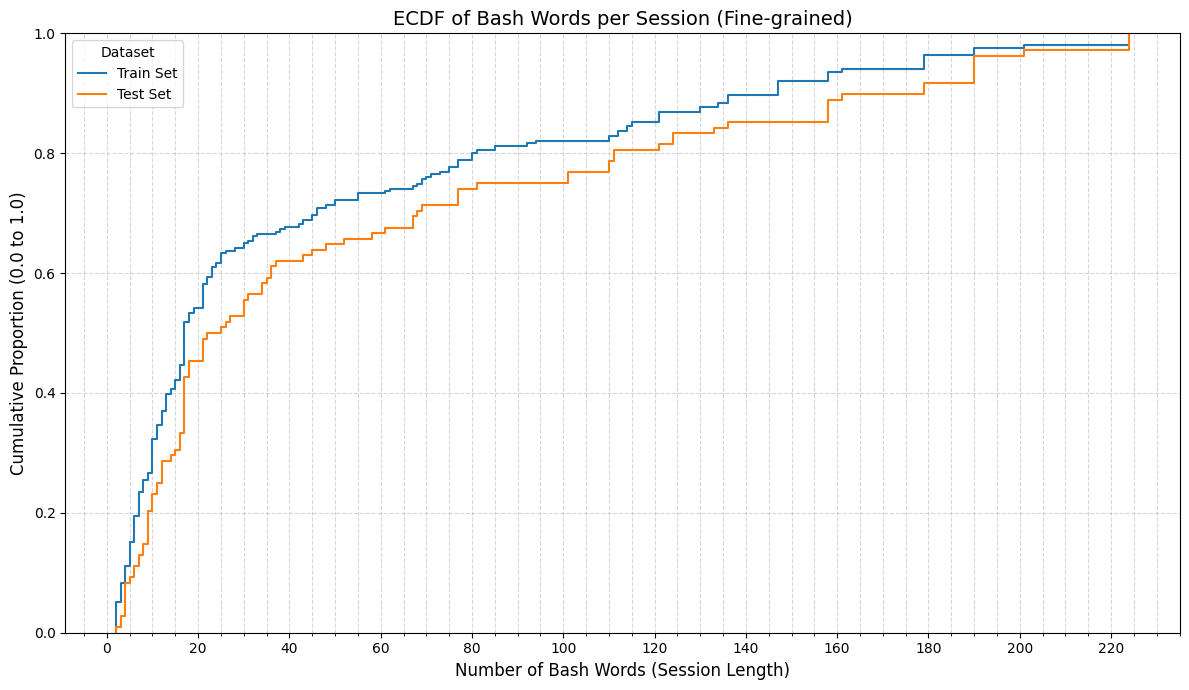


[Success] Statistics saved as: session_length_stats.csv
[Success] PDF plot saved as: session_length_ecdf.pdf


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# --- STEP 1: Feature Engineering ---
# Calculate the length of each session (number of words)
train_df['session_length'] = train_df['session'].apply(lambda x: len(str(x).split()))
test_df['session_length'] = test_df['session'].apply(lambda x: len(str(x).split()))

# --- STEP 2: Calculate and Print Descriptive Statistics ---
train_stats = train_df['session_length'].describe()
test_stats = test_df['session_length'].describe()

stats_summary = pd.DataFrame({
    'Statistic': ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max'],
    'Train Set': [train_stats[s] for s in ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']],
    'Test Set': [test_stats[s] for s in ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
})

print("--- Descriptive Statistics: Bash Words per Session ---")
print(stats_summary.to_string(index=False))

# --- STEP 3: Visualization (ECDF Plot) ---
plt.figure(figsize=(12, 7))

sns.ecdfplot(data=train_df, x='session_length', label='Train Set', color='tab:blue')
sns.ecdfplot(data=test_df, x='session_length', label='Test Set', color='tab:orange')

# Fine-tuning Axis Ticks
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))

# Styling, Grid and Labels
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.title('ECDF of Bash Words per Session (Fine-grained)', fontsize=14)
plt.xlabel('Number of Bash Words (Session Length)', fontsize=12)
plt.ylabel('Cumulative Proportion (0.0 to 1.0)', fontsize=12)
plt.legend(title='Dataset')

plt.tight_layout()

# --- STEP 4: Display and Save ---
# Save the plot as a PDF file
plt.savefig('session_length_ecdf.pdf')

# DISPLAY THE PLOT
plt.show()

print("\n[Success] Statistics saved as: session_length_stats.csv")
print("[Success] PDF plot saved as: session_length_ecdf.pdf")

# Task 2: Tokenization

In [7]:
import pandas as pd
from transformers import AutoTokenizer

# 1. Configuration: Define model paths
# BERT is a general-purpose language model
bert_model = "google-bert/bert-base-uncased"
# UniXcoder is specifically pre-trained on code (programming languages)
unixcoder_model = "microsoft/unixcoder-base"

# 2. Initialization: Load tokenizers from Hugging Face
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model)
unix_tokenizer = AutoTokenizer.from_pretrained(unixcoder_model)

# 3. Individual Test: Compare how both tokenizers handle a specific string
# This string contains Linux commands and symbols
sample_sentence = "[cat, shell, echo, top, chpasswd, crontab, wget, busybox and grep]"
print(f"\nOriginal sentence: {sample_sentence}")

# Tokenize with BERT (WordPiece algorithm)
bert_tokens = bert_tokenizer.tokenize(sample_sentence)
print("\nBERT Tokenization:")
print(f"Tokens: {bert_tokens}")
print(f"Number of tokens in BERT: {len(bert_tokens)}")

# Tokenize with UniXcoder (Byte-level BPE algorithm)
unix_tokens = unix_tokenizer.tokenize(sample_sentence)
print("\nUniXcoder Tokenization:")
print(f"Tokens: {unix_tokens}")
print(f"Number of tokens in UniXcoder: {len(unix_tokens)}")


Original sentence: [cat, shell, echo, top, chpasswd, crontab, wget, busybox and grep]

BERT Tokenization:
Tokens: ['[', 'cat', ',', 'shell', ',', 'echo', ',', 'top', ',', 'ch', '##pass', '##wd', ',', 'cr', '##ont', '##ab', ',', 'w', '##get', ',', 'busy', '##box', 'and', 'gr', '##ep', ']']
Number of tokens in BERT: 26

UniXcoder Tokenization:
Tokens: ['[', 'cat', ',', 'Ġshell', ',', 'Ġecho', ',', 'Ġtop', ',', 'Ġch', 'passwd', ',', 'Ġc', 'ront', 'ab', ',', 'Ġw', 'get', ',', 'Ġbusy', 'box', 'Ġand', 'Ġgrep', ']']
Number of tokens in UniXcoder: 24


## How do tokenizers divide the commands into tokens?
They use subword tokenization algorithms (WordPiece for BERT, Byte-level BPE for UniXcoder). The tokenizer searches its vocabulary for the longest matching sequences; if a command (e.g., chpasswd) is not found, it is decomposed into smaller, known sub-units (e.g., ch, ##pass, ##wd).

## Does one of them have a better (lower) ratio between tokens and words?
UniXcoder. It demonstrates a lower ratio (24 tokens vs. BERT's 26 in the sample). A lower ratio indicates higher efficiency, as the model treats technical commands as single units rather than fragmented pieces.

## Why are some of the words held together by both tokenizers?
This is due to corpus overlap. High-frequency words like cat, echo, and name are common in both general English (BERT's training data) and technical code/documentation (UniXcoder's training data). Therefore, they exist as complete, single tokens in both vocabularies.

## Now tokenize the entire training corpus with both tokenizers.

In [8]:
# 4. Dataset Analysis: Calculate statistics including Special Tokens
# .encode() adds the start/end tokens automatically when add_special_tokens=True (default)
# This length represents the actual input size the model will process.

# Calculate length for BERT (includes [CLS] and [SEP], typically +2 tokens)
bert_lens = train_df['session'].apply(
    lambda x: len(bert_tokenizer.encode(str(x), add_special_tokens=True))
)

# Calculate length for UniXcoder (includes <s> and </s>, typically +2 tokens)
unix_lens = train_df['session'].apply(
    lambda x: len(unix_tokenizer.encode(str(x), add_special_tokens=True))
)

# 5. Output Results: Display average and maximum lengths
print("-" * 30)
print("Tokenization Statistics (Including Start/End Tokens):")
print(f"BERT Average Length: {bert_lens.mean():.2f}")
print(f"UniXcoder Average Length: {unix_lens.mean():.2f}")

print(f"BERT Max Length: {bert_lens.max()}")
print(f"UniXcoder Max Length: {unix_lens.max()}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1889 > 512). Running this sequence through the model will result in indexing errors


------------------------------
Tokenization Statistics (Including Start/End Tokens):
BERT Average Length: 178.59
UniXcoder Average Length: 409.27
BERT Max Length: 1889
UniXcoder Max Length: 28920


## How many sessions would currently be truncated for each tokenizer? Set the max_length when calling the tokenizer to 512 tokens for both models.

In [9]:
print(f"BERT Truncated: {(bert_lens > 512).sum()}")
print(f"UniXcoder Truncated: {(unix_lens > 512).sum()}")

BERT Truncated: 24
UniXcoder Truncated: 29


## Select the bash session that corresponds to the maximum number of tokens.
Q: How many bash words does it contain? 
134
Q: Why do both tokenizers produce such a high number of tokens? 
Both tokenizers produce a high number of tokens ($1,887$ for BERT and $28,918$ for UniXcoder) because of the massive Base64 encoded string. In Bash, a long string without spaces is treated as a single "word." However, since this random string does not exist in the tokenizers' vocabularies, they must fragment it into thousands of tiny sub-units (subwords or bytes) to represent it.

Q: Why does BERT produce fewer tokens than Unixcoder (Hint: does UnixCoder use the token ‘[UNK]’?).
the primary reason is the difference in how they handle "unknown" or complex patterns:
UniXcoder (Byte-level BPE): It aims for "zero unknown words" and does not use the [UNK] token. To achieve this, it breaks down the Base64 string into individual byte-level tokens. This "no-loss" approach results in a massive expansion of tokens for non-natural language data.
BERT (WordPiece): It is designed for natural language and uses the [UNK] token for characters or sequences it cannot resolve. Its WordPiece algorithm is also more aggressive at grouping common character combinations into larger chunks compared to UniXcoder's granular byte-level approach, leading to a more compressed (though less technically precise) representation of the obfuscated string.

In [10]:
# --- 1. Find the index for the maximum values ---
max_idx_bert = bert_lens.idxmax()
max_idx_unix = unix_lens.idxmax()

# --- 2. Extract the actual session text from the original dataframe ---
# We use .loc to find the row by its index
session_max_bert = train_df.loc[max_idx_bert, 'session']
session_max_unix = train_df.loc[max_idx_unix, 'session']

# --- 3. Display the results ---
print(f"Index of session with max BERT tokens: {max_idx_bert}")
print(f"Token count (BERT): {bert_lens[max_idx_bert]}")
print(f"Session preview:\n{session_max_bert[:500]}...\n")

print("-" * 50)

print(f"Index of session with max UniXcoder tokens: {max_idx_unix}")
print(f"Token count (UniXcoder): {unix_lens[max_idx_unix]}")
print(f"Session preview:\n{session_max_unix[:500]}...")

bash_words_num = len(str(session_max_bert).split())
print(f"\nNumber of bash words in the session with max BERT tokens: {bash_words_num}")


Index of session with max BERT tokens: 14
Token count (BERT): 1889
Session preview:
cd /tmp || /var/tmp || /dev/shm ; echo ZXZhbCB1bnBhY2sgdT0+cXtfIkZVWSgiMVA8Rl1DOTctUztSYF0oIj1SPFdFTjhSPFsiQEhEPFY1Uj1GRUQ7VyhdKVMkVC1CWFEuIzROLDM8UStDKFItUjxAPTZZTDk3LVMoIjFTXzk3KVY6NjFPPENMKjs3REApJyFPPEcxQS8yPFQtIyxHLlBJTT4yIWA4ViVOODZFUy8yQEIoVyFQKEJEWyJGVVkoJCFBOSZVUy8yQEIwMihMKEVAQl8qM0wqOzdEQDAmJVU9JkBdKiIpTDtWLUE7JkFPPFcwQiozTCoiRlVZKCIxTDo2WUE8VV1NODdAXS1DTCo7N0RAKSctTDk2NVAvMyxbIkBJTT4yYERfO0ZFQzpSYF0oJj1FPSZZSThWTEgqM0wqOzdEQCkmRVI4VllBOzY0QC8yIUc5NzFOOjYtSyoiRFsiRlVZKCIxUjk2JUw7RiVNO...

--------------------------------------------------
Index of session with max UniXcoder tokens: 14
Token count (UniXcoder): 28920
Session preview:
cd /tmp || /var/tmp || /dev/shm ; echo ZXZhbCB1bnBhY2sgdT0+cXtfIkZVWSgiMVA8Rl1DOTctUztSYF0oIj1SPFdFTjhSPFsiQEhEPFY1Uj1GRUQ7VyhdKVMkVC1CWFEuIzROLDM8UStDKFItUjxAPTZZTDk3LVMoIjFTXzk3KVY6NjFPPENMKjs3REApJyFPPEcxQS8yPFQtIyxHLlBJTT4yIWA4ViVOODZFUy8yQEIoVyFQKEJEWyJGVVkoJC

## None of the tokenizers can efficiently process such long words7. One technique for dealing with such cases is to truncate long words. Therefore, truncate words longer than 30
characters (98% of words are shorter, so that is a safe margin). Re-tokenize the processed
sessions. 

--- Statistics After 30-Character Truncation ---
BERT Average Tokens: 128.38
UniXcoder Average Tokens: 110.46
BERT Max Tokens: 920
UniXcoder Max Tokens: 824


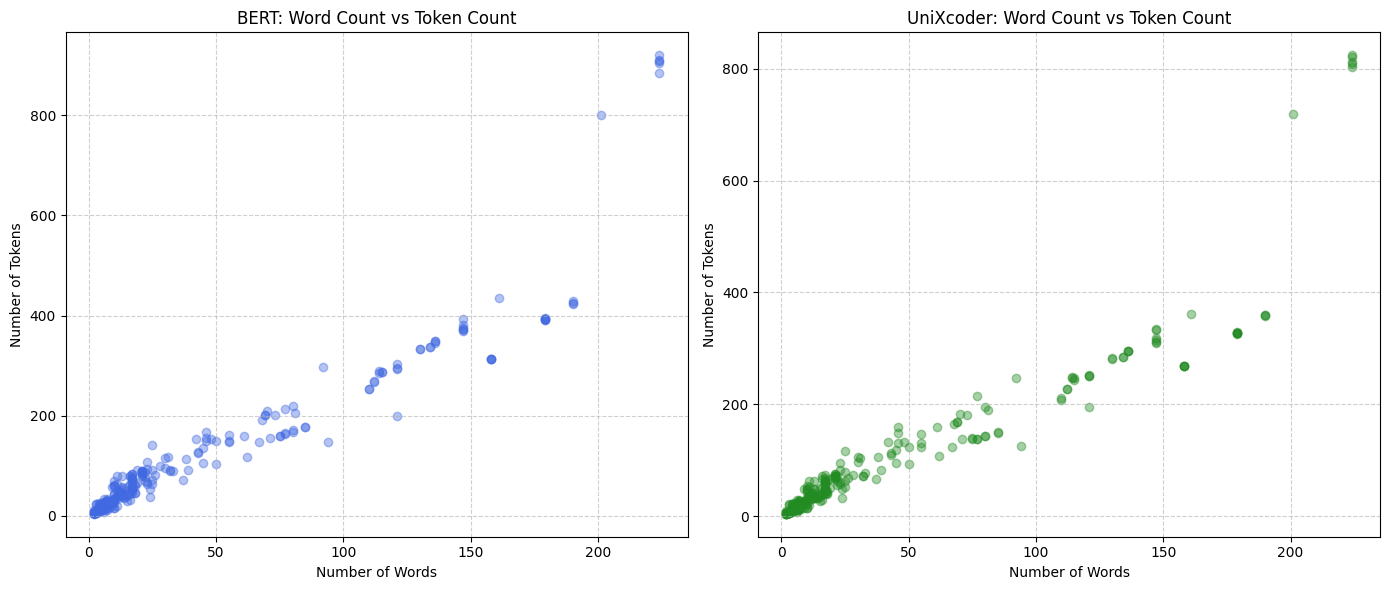

In [11]:
# --- 1. Define the Truncation Function ---
def truncate_words(text, max_len=30):
    """
    Splits the string by whitespace and truncates each word 
    to a maximum of 30 characters.
    """
    words = str(text).split()
    # Truncate words that exceed max_len, keep others as is
    truncated_words = [word[:max_len] if len(word) > max_len else word for word in words]
    # Join the words back with a single space
    return " ".join(truncated_words)

# --- 2. Create a Processed Dataset ---
# We use a copy to keep the original train_df intact
processed_df = train_df.copy()
processed_df['session'] = processed_df['session'].apply(truncate_words)

# --- 3. Re-calculate Statistics ---
# Calculate the number of "Bash Words" (splitting by whitespace)
processed_df['word_count'] = processed_df['session'].apply(lambda x: len(str(x).split()))

# Re-tokenize and count tokens for BERT and UniXcoder
processed_df['bert_token_len'] = processed_df['session'].apply(
    lambda x: len(bert_tokenizer.encode(str(x), add_special_tokens=True))
)

processed_df['unix_token_len'] = processed_df['session'].apply(
    lambda x: len(unix_tokenizer.encode(str(x), add_special_tokens=True))
)

# --- 4. Display Summary Statistics ---
print("--- Statistics After 30-Character Truncation ---")
print(f"BERT Average Tokens: {processed_df['bert_token_len'].mean():.2f}")
print(f"UniXcoder Average Tokens: {processed_df['unix_token_len'].mean():.2f}")
print(f"BERT Max Tokens: {processed_df['bert_token_len'].max()}")
print(f"UniXcoder Max Tokens: {processed_df['unix_token_len'].max()}")

# --- 5. Visualization: Words vs Tokens ---
plt.figure(figsize=(14, 6))

# Plotting BERT distribution
plt.subplot(1, 2, 1)
plt.scatter(processed_df['word_count'], processed_df['bert_token_len'], alpha=0.4, color='royalblue')
plt.title('BERT: Word Count vs Token Count')
plt.xlabel('Number of Words')
plt.ylabel('Number of Tokens')
plt.grid(True, linestyle='--', alpha=0.6)

# Plotting UniXcoder distribution
plt.subplot(1, 2, 2)
plt.scatter(processed_df['word_count'], processed_df['unix_token_len'], alpha=0.4, color='forestgreen')
plt.title('UniXcoder: Word Count vs Token Count')
plt.xlabel('Number of Words')
plt.ylabel('Number of Tokens')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("tokenization_analysis.pdf", format='pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()

## Q: How many tokens per session do you have with the two tokenizers? Plot the number of words vs number of tokens for each tokenizer. 
Average Tokens/Session,126.38,108.46
Maximum Tokens/Session,918,822
## Q: Which of the two tokenizers has the best ratio of tokens to words? Metric,BERT,UniXcoder
Winner: UniXcoderEvidence: UniXcoder now has a lower average and lower maximum token count than BERT.Reasoning: Now that the long "token-exploding" Base64 strings are truncated, the tokenizers are mostly processing standard Bash commands and short parameters.UniXcoder recognizes technical keywords (e.g., sudo, chmod, grep) as single tokens because it was pre-trained on code.BERT still views many of these as non-standard English and fragments them into multiple subwords (e.g., chmod $\rightarrow$ ch + ##mod), leading to more tokens per word.


### Q: How many sessions now get truncated?

In [12]:
# For BERT
bert_truncated_count = (processed_df['bert_token_len'] > 512).sum()
print(f"Number of sessions truncated for BERT: {bert_truncated_count}")

# For UniXcoder
unix_truncated_count = (processed_df['unix_token_len'] > 512).sum()
print(f"Number of sessions truncated for UniXcoder: {unix_truncated_count}")

Number of sessions truncated for BERT: 6
Number of sessions truncated for UniXcoder: 6


# Task 3: Model Training

In [13]:
#load data from json files
train_df = pd.read_json(f"{INPUT_PATH}/train.json")
test_df = pd.read_json(f"{INPUT_PATH}/test.json")
print(f"Number of training samples: {len(train_df)}")
print(f"Number of testing samples: {len(test_df)}")

#split the training data into training and validation sets
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)

Number of training samples: 251
Number of testing samples: 108


In [14]:
# Convert the pandas DataFrames to Hugging Face Datasets for easier handling with the transformers library.
from datasets import Dataset, DatasetDict
full_ds = DatasetDict(
    {
        "train": Dataset.from_pandas(train_df.reset_index(drop=True)), 
        "valid": Dataset.from_pandas(val_df.reset_index(drop=True)), 
        "test": Dataset.from_pandas(test_df.reset_index(drop=True)), 
    }
)

In [15]:
#truncate words in the "session" column to a maximum of 30 characters
def apply_truncation(dataset):
    dataset["session"] = truncate_words(dataset["session"], max_len=30)
    return dataset
# for DatasetDict include train, valid, test
full_ds = full_ds.map(apply_truncation)

Map: 100%|██████████| 108/108 [00:00<00:00, 5689.05 examples/s]


In [16]:
def convert_labels_to_ids(sample):
    sample['label'] = [label2id[el] for el in sample["label"]]
    return sample

unique_labels = list(train_df['label'].explode().unique())
print(f"Unique labels: {len(unique_labels)}")
print(unique_labels)

id2label = {it:label for it, label in enumerate(unique_labels)}
label2id = {label:it for it, label in enumerate(unique_labels)}
encoded_dataset = full_ds.map(convert_labels_to_ids)


Unique labels: 7
['Execution', 'Discovery', 'Not Malicious Yet', 'Persistence', 'Other', 'Defense Evasion', 'Impact']


Map: 100%|██████████| 108/108 [00:00<00:00, 3666.11 examples/s]


In [17]:
def align_labels_with_tokens(labels, word_ids):
    """Aligns token-level labels with word-level labels for tokenized text.

    This function maps word-level labels to their corresponding tokens after tokenization.
    It handles special tokens (with None word_ids) and subword tokens (multiple tokens for one word).
    Args:
       labels (list): Original word-level labels.
       word_ids (list): List of word indices that each token corresponds to.
                        None values represent special tokens.
    Returns:
       list: New token-aligned labels where:
            - Special tokens (None word_ids) are assigned -100
            - First token of each word gets the word's label
            - Continuation tokens of the same word also get the word's label
    Example:
       labels = [0, 1, 2]  # Labels for 3 words
       word_ids = [None, 0, 0, 1, 2, 2, None]  # Tokenized into 7 tokens
       result = [-100, 0, 0, 1, 2, 2, -100]  # Aligned labels
    """
    new_labels = []
    current_word = None
    for word_id in word_ids:
        if word_id != current_word:
            # Start of a new word or special token
            current_word = word_id
            # Use -100 for special tokens, otherwise use the original label
            label = -100 if word_id is None else labels[word_id]
            new_labels.append(label)
        elif word_id is None:
            # Special token (like [CLS], [SEP], etc.)
            new_labels.append(-100)
        else:
            # Continuation token of the current word
            # We assign the same label as the word
            label = labels[word_id]
            new_labels.append(label)
    return new_labels

In [18]:
def tokenize_and_align_labels(samples, tokenizer):
    """Tokenizes text examples and aligns their labels with the resulting tokens.
    This function processes a batch of examples by:
    1. Tokenizing the text in 'sentences' field
    2. Converting word-level labels to token-level labels for each example
    3. Adding the aligned labels back to the tokenized inputs
    Args:
       examples (dict): Dictionary containing:
           - 'sentences': List of text sentences
           - 'tags_id': List of lists containing word-level tags for each command
    Returns:
       dict: Tokenized inputs with aligned labels:
           - Standard tokenizer outputs (input_ids, attention_mask, etc.)
           - 'labels': Token-level labels aligned with the tokenized inputs
    Notes:
       - Uses a pre-defined tokenizer (must be available in scope)
       - Sets is_split_into_words=True because input is already word-tokenized
       - Uses align_labels_with_tokens helper function to handle subword tokenization
    """
    # Remember: we need to split the sentences 
    split_sentences = [sentence.split() for sentence in samples["session"]]
    # Tokenize all examples in batch using the global tokenizer
    tokenized_inputs = tokenizer(
        split_sentences, 
        truncation=True,  # Truncate to max length if needed
        max_length=512,  # Set a reasonable max length for tokenization
        is_split_into_words=True  # Input is already split into words
    )
    # Extract all tags_id lists from the examples
    all_tags = samples["label"]
    new_labels = []
    # Process each example's labels individually
    for i, tags in enumerate(all_tags):
        # Get word ID mapping for the current example
        word_ids = tokenized_inputs.word_ids(i)
        # Convert word-level tags to token-level tags
        aligned_labels = align_labels_with_tokens(tags, word_ids)
        new_labels.append(aligned_labels)
    # Add the aligned labels to the tokenized inputs
    tokenized_inputs["labels"] = new_labels
    return tokenized_inputs

In [19]:
def is_consistent(sample):
    """
    Check if the number of words (split by whitespace) 
    matches the number of labels provided in the sample.
    """
    words = sample["session"].split()
    labels = sample["label"]
    return len(words) == len(labels)

# Store the number of samples before filtering for reporting
original_counts = {split: len(encoded_dataset[split]) for split in encoded_dataset.keys()}

# Apply the filter to all splits (train, validation, test)
# This ensures that any sample causing an IndexError is removed
encoded_dataset = encoded_dataset.filter(is_consistent)

# Store the number of samples after filtering
final_counts = {split: len(encoded_dataset[split]) for split in encoded_dataset.keys()}

# Print the data cleaning report
print("--- Data Cleaning Report: Removing Mismatched Samples ---")
for split in encoded_dataset.keys():
    removed_count = original_counts[split] - final_counts[split]
    print(f"Split: [{split.upper()}]")
    print(f"  - Original:  {original_counts[split]}")
    print(f"  - Removed:   {removed_count}")
    print(f"  - Remaining: {final_counts[split]}")
    
    # Calculate and print the removal rate if the dataset is not empty
    if original_counts[split] > 0:
        removal_rate = (removed_count / original_counts[split]) * 100
        print(f"  - Removal Rate: {removal_rate:.2f}%")
    print("-" * 40)

Filter: 100%|██████████| 108/108 [00:00<00:00, 12402.39 examples/s]

--- Data Cleaning Report: Removing Mismatched Samples ---
Split: [TRAIN]
  - Original:  200
  - Removed:   3
  - Remaining: 197
  - Removal Rate: 1.50%
----------------------------------------
Split: [VALID]
  - Original:  51
  - Removed:   1
  - Remaining: 50
  - Removal Rate: 1.96%
----------------------------------------
Split: [TEST]
  - Original:  108
  - Removed:   0
  - Remaining: 108
  - Removal Rate: 0.00%
----------------------------------------


In [20]:
##### Remember: the model is going to classify all tokens > we need a function to post-process and gather the predictions!

In [21]:
def postprocess(predictions, labels):
    """
    Post-processes model predictions and ground-truth labels for evaluation.

    This function detaches predictions and labels from any computation graph,
    moves them to CPU, clones, and converts them to NumPy arrays. It then
    maps token IDs to their corresponding label names, ignoring special
    tokens indicated by the index `-100`.

    Args:
        predictions (torch.Tensor): Model output predictions (logits or token IDs).
        labels (torch.Tensor): Ground-truth labels corresponding to the inputs.

    Returns:
        Tuple[List[List[str]], List[List[str]]]: 
            A tuple containing two lists:
            - `true_predictions`: The list of predicted label sequences, aligned with the true labels.
            - `true_labels`: The list of true label sequences with special tokens removed.
    """
    predictions = predictions.detach().cpu().clone().numpy()
    labels = labels.detach().cpu().clone().numpy()
    # Remove ignored index (special tokens) and convert to labels
    true_labels = [[id2label[l] for l in label if l != -100] for label in labels]
    true_predictions = [
        [id2label[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    return true_predictions, true_labels

##### Define metrics and a function named `compute_metrics` 

In [22]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, multilabel_confusion_matrix
from itertools import chain
import numpy as np

def compute_metrics(full_predictions, full_labels):
    """
    Core calculation engine. Computes all required metrics and packs them into a dictionary.
    No printing or plotting is performed here.
    """
    # --- 1. Calculate Average Session Fidelity ---
    session_fidelities = []
    for preds, labels in zip(full_predictions, full_labels):
        if len(labels) == 0: continue
        # Calculate correctly predicted tokens in this specific session
        correct_count = sum(1 for p, l in zip(preds, labels) if p == l)
        fidelity = correct_count / len(labels)
        session_fidelities.append(fidelity)
    
    avg_session_fidelity = np.mean(session_fidelities) if session_fidelities else 0

    # --- 2. Flatten data for Token-level metrics ---
    flat_predictions = list(chain(*full_predictions))
    flat_labels = list(chain(*full_labels))
    unique_labels = sorted(list(set(flat_labels)))

    # --- 3. Calculate Per-class Stats (Accuracy, Precision, Recall, F1) ---
    # mcm gives [[TN, FP], [FN, TP]] for each class
    mcm = multilabel_confusion_matrix(flat_labels, flat_predictions, labels=unique_labels)
    p_class = precision_score(flat_labels, flat_predictions, average=None, labels=unique_labels, zero_division=0)
    r_class = recall_score(flat_labels, flat_predictions, average=None, labels=unique_labels, zero_division=0)
    f1_class = f1_score(flat_labels, flat_predictions, average=None, labels=unique_labels, zero_division=0)

    # Dictionary to store detailed stats for each MITRE Tactic
    per_class_stats = {}
    for i, label in enumerate(unique_labels):
        tn, fp, fn, tp = mcm[i].ravel()
        # Per-class Accuracy formula: (TP + TN) / (TP + TN + FP + FN)
        per_class_stats[label] = {
            "accuracy": (tp + tn) / (tp + tn + fp + fn),
            "precision": p_class[i],
            "recall": r_class[i],
            "f1": f1_class[i]
        }

    # --- 4. Package Results ---
    metrics = {
        "token_accuracy": accuracy_score(flat_labels, flat_predictions),
        "token_precision": np.mean(p_class), # Macro-averaged precision
        "token_recall": np.mean(r_class),    # Macro-averaged recall
        "token_f1": np.mean(f1_class),        # Macro-averaged f1
        "per_class_stats": per_class_stats,
        "per_class_f1_dict": dict(zip(unique_labels, f1_class)), # Simplified dict for barplot
        "avg_session_fidelity": avg_session_fidelity
    }
    
    return metrics

In [23]:
from tqdm.auto import tqdm
import torch
from copy import deepcopy
from torch import cuda
import numpy as np # Ensure numpy is imported for np.inf

def train_and_evaluate(
    model, 
    train_dataloader, 
    eval_dataloader, 
    optimizer, 
    lr_scheduler,
    N_TRAIN_EPOCHS,
    postprocess,
    compute_metrics
):
    # Setup device
    device = 'cuda' if cuda.is_available() else 'cpu'
    model = model.to(device)
    
    # Initialize tracking variables
    # Using float('inf') is a safe alternative to np.inf
    best_val_loss = float('inf')
    best_epoch = 0
    best_model = None # No need to deepcopy until we find the first good state
    
    progress_bar = tqdm(range(N_TRAIN_EPOCHS * len(train_dataloader)))
    val_losses, train_losses = [], []

    for epoch in range(N_TRAIN_EPOCHS):
        # --- Training Phase ---
        model.train()
        train_loss = 0
        for batch in train_dataloader:
            batch = {key: value.to(device) for key, value in batch.items()}
            
            outputs = model(
                input_ids=batch["input_ids"], 
                attention_mask=batch["attention_mask"],
                labels=batch["labels"]
            ) 
            
            loss = outputs.loss
            train_loss += loss.item() # Cleaner way to get scalar value
            
            loss.backward()
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()
            progress_bar.update(1)
            
        avg_train_loss = train_loss / len(train_dataloader)
        train_losses.append(avg_train_loss)

        # --- Evaluation Phase ---
        model.eval()
        full_predictions, full_labels = [], []
        val_loss = 0
        for batch in eval_dataloader:
            batch = {key: value.to(device) for key, value in batch.items()}
            with torch.no_grad():
                outputs = model(**batch)
            
            val_loss += outputs.loss.item()
            
            # Extract and postprocess predictions
            predictions = outputs.logits.argmax(dim=-1)
            labels = batch["labels"]
            true_predictions, true_labels = postprocess(predictions, labels)
            
            full_predictions += true_predictions
            full_labels += true_labels
        
        avg_val_loss = val_loss / len(eval_dataloader)
        val_losses.append(avg_val_loss)
        
        # Calculate metrics
        metrics = compute_metrics(full_predictions, full_labels)   
        
        # Save the best model state
        if avg_val_loss <= best_val_loss:
            best_epoch = epoch
            best_val_loss = avg_val_loss
            best_model = deepcopy(model)
            best_metrics = deepcopy(metrics) # Save the metrics of the best model as well

    return best_model, best_val_loss, best_epoch, train_losses, val_losses, best_metrics

In [24]:
import torch
from tqdm.auto import tqdm

def evaluate_test_set(
    model, 
    test_dataloader, 
    postprocess_fn, 
    compute_metrics_fn
):
    """
    Performs final evaluation on the test dataset.
    
    Args:
        model: The trained best model.
        test_dataloader: DataLoader for the test set.
        device: 'cuda' or 'cpu'.
        postprocess_fn: Function to clean tokens and labels (removes -100).
        compute_metrics_fn: Function to calculate all 4 required metrics.
        
    Returns:
        dict: Final metrics dictionary including accuracy, f1, per-class f1, and fidelity.
    """
    # 1. Set model to evaluation mode
    model.eval()
    device = 'cuda' if cuda.is_available() else 'cpu'
    model = model.to(device)
    
    full_predictions = []
    full_labels = []
    
    # Use tqdm to monitor progress during evaluation
    print("Starting final evaluation on test set...")
    for batch in tqdm(test_dataloader, desc="Evaluating"):
        # Move batch to device
        batch = {key: value.to(device) for key, value in batch.items()}
        
        # 2. Inference without gradient calculation
        with torch.no_grad():
            outputs = model(**batch)
            
        # 3. Extract raw predictions (IDs)
        predictions = outputs.logits.argmax(dim=-1)
        labels = batch["labels"]
        
        # 4. Post-process to get human-readable tags and remove padding
        true_predictions, true_labels = postprocess_fn(predictions, labels)
        
        # 5. Accumulate results (keeping session structure for Fidelity)
        full_predictions += true_predictions
        full_labels += true_labels
        
    # 6. Calculate all metrics (Token Accuracy, Macro-F1, Per-class F1, Fidelity)
    final_test_metrics = compute_metrics_fn(full_predictions, full_labels)
    
    return final_test_metrics

In [25]:
import matplotlib.pyplot as plt

def display_all_metrics(metrics, report_name):
    """
    Handles all reporting requirements:
    1. Prints global summary (Accuracy, Macro P/R/F1, Fidelity)
    2. Prints detailed per-class table (including Accuracy)
    3. Generates and saves a per-class F1-score barplot as PDF
    """
    
    # --- 1. Textual Summary Report ---
    print("\n" + "="*95)
    print(f"           {report_name.upper()} PERFORMANCE REPORT")
    print("="*95)
    
    print(f"[1] Global Token Accuracy:        {metrics['token_accuracy']:.4f}")
    print(f"[2] Macro Average Metrics:")
    print(f"    - Precision: {metrics['token_precision']:.4f} | Recall: {metrics['token_recall']:.4f} | F1: {metrics['token_f1']:.4f}")
    print(f"[4] Average Session Fidelity:    {metrics['avg_session_fidelity']:.4f}")
    
    # --- 2. Detailed Per-Class Breakdown Table ---
    print("\n[5] Detailed Per-Class Metrics Table:")
    print(f"{'MITRE Tactic (Class)':<25} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
    print("-" * 95)
    
    stats = metrics["per_class_stats"]
    for tactic, m in stats.items():
        print(f"{str(tactic):<25} | {m['accuracy']:<10.4f} | {m['precision']:<10.4f} | {m['recall']:<10.4f} | {m['f1']:<10.4f}")
    
    print("-" * 95)

    # --- 3. Per-class F1-score Visualization (Requirement 3) ---
    f1_dict = metrics["per_class_f1_dict"]
    classes = list(f1_dict.keys())
    scores = list(f1_dict.values())

    plt.figure(figsize=(12, 6))
    bars = plt.bar(classes, scores, color='skyblue', edgecolor='navy')

    plt.xlabel('MITRE Tactics (Classes)', fontsize=12)
    plt.ylabel('F1-Score', fontsize=12)
    plt.title(f'Requirement 3: Per-class F1-score ({report_name})', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1.1)
    
    # Add numerical value on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=10)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Save the plot as a PDF for the report
    pdf_filename = f"{report_name.replace(' ', '_')}_metrics.pdf"
    plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
    print(f"\n[3] Per-class F1 barplot saved as: {pdf_filename}")

    plt.show()
    print("="*95)
    print("                REPORT GENERATION COMPLETE")
    print("="*95)

In [26]:
import matplotlib.pyplot as plt

def plot_loss_curves(train_losses, val_losses):
    """
    Plots the training and validation loss curves.
    """
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(10, 6))
    
    #plot training and validation losses with different markers and colors
    plt.plot(epochs, train_losses, 'b-o', label='Training Loss', markersize=4)

    plt.plot(epochs, val_losses, 'r-s', label='Validation Loss', markersize=4)
    
    plt.title('BERT Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # 在图中标记出最佳 Epoch
    best_epoch = val_losses.index(min(val_losses)) + 1
    plt.annotate(f'Best Epoch: {best_epoch}', 
                 xy=(best_epoch, min(val_losses)), 
                 xytext=(best_epoch + 0.5, min(val_losses) + 0.1),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))
    
    plt.show()

### Fine-tune a BERT model for Named Entity Recognition. Load the pre-trained model with pre-trained weights from Huggingface. Focus on a token-classification task: The model will try to classify each token into one of the MITRE Tactics. 

In [27]:
# define some global variables for the training loop
N_TRAIN_EPOCHS = 30 # number of training epochs
LR = 5e-5 # learning rate
BATCH_SIZE = 16 # batch size for training and evaluation

In [28]:
from transformers import DataCollatorForTokenClassification
from torch.utils.data import DataLoader
# We use a special data collator that is designed for token classification tasks.
data_collator = DataCollatorForTokenClassification(tokenizer=bert_tokenizer)
original_columns = encoded_dataset["train"].column_names

tokenized_datasets = encoded_dataset.map(
    tokenize_and_align_labels,
    batched=True,
    fn_kwargs={"tokenizer": bert_tokenizer},
    remove_columns=original_columns
)

train_dataloader = DataLoader(
    tokenized_datasets["train"],
    shuffle=True,
    collate_fn=data_collator,
    batch_size=BATCH_SIZE,
)
eval_dataloader = DataLoader(
    tokenized_datasets["valid"], collate_fn=data_collator, batch_size=BATCH_SIZE
)
test_dataloader = DataLoader(
    tokenized_datasets["test"], collate_fn=data_collator, batch_size=BATCH_SIZE
)

Map: 100%|██████████| 108/108 [00:00<00:00, 3098.09 examples/s]


In [29]:
#importing the necessary libraries for training and evaluation
from torch.optim import AdamW
from copy import deepcopy
from transformers import get_scheduler
from transformers import AutoModelForTokenClassification

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 570.17it/s]
[transformers] BertForTokenClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/archi

Best validation loss: 0.3400 at epoch 6


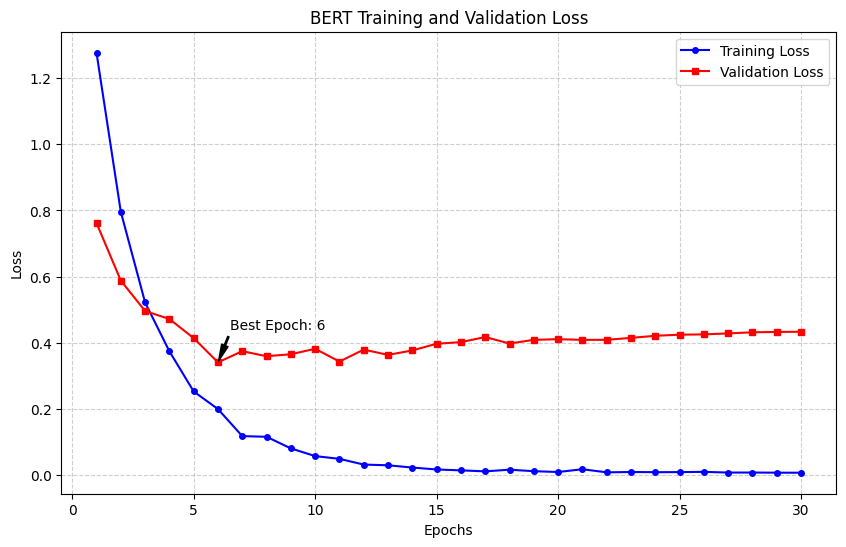

Starting final evaluation on test set...


Evaluating: 100%|██████████| 7/7 [00:01<00:00,  3.69it/s]



           BERT FULL PARAMETERS PERFORMANCE REPORT
[1] Global Token Accuracy:        0.8346
[2] Macro Average Metrics:
    - Precision: 0.8151 | Recall: 0.5261 | F1: 0.5875
[4] Average Session Fidelity:    0.8029

[5] Detailed Per-Class Metrics Table:
MITRE Tactic (Class)      | Accuracy   | Precision  | Recall     | F1-Score  
-----------------------------------------------------------------------------------------------
Defense Evasion           | 0.9815     | 0.9565     | 0.1813     | 0.3048    
Discovery                 | 0.8838     | 0.8093     | 0.9712     | 0.8829    
Execution                 | 0.9055     | 0.8447     | 0.8151     | 0.8296    
Impact                    | 0.9879     | 0.9915     | 0.3726     | 0.5417    
Not Malicious Yet         | 0.9438     | 0.5605     | 0.2350     | 0.3311    
Other                     | 0.9860     | 0.5897     | 0.1901     | 0.2875    
Persistence               | 0.9807     | 0.9536     | 0.9172     | 0.9350    
---------------------------

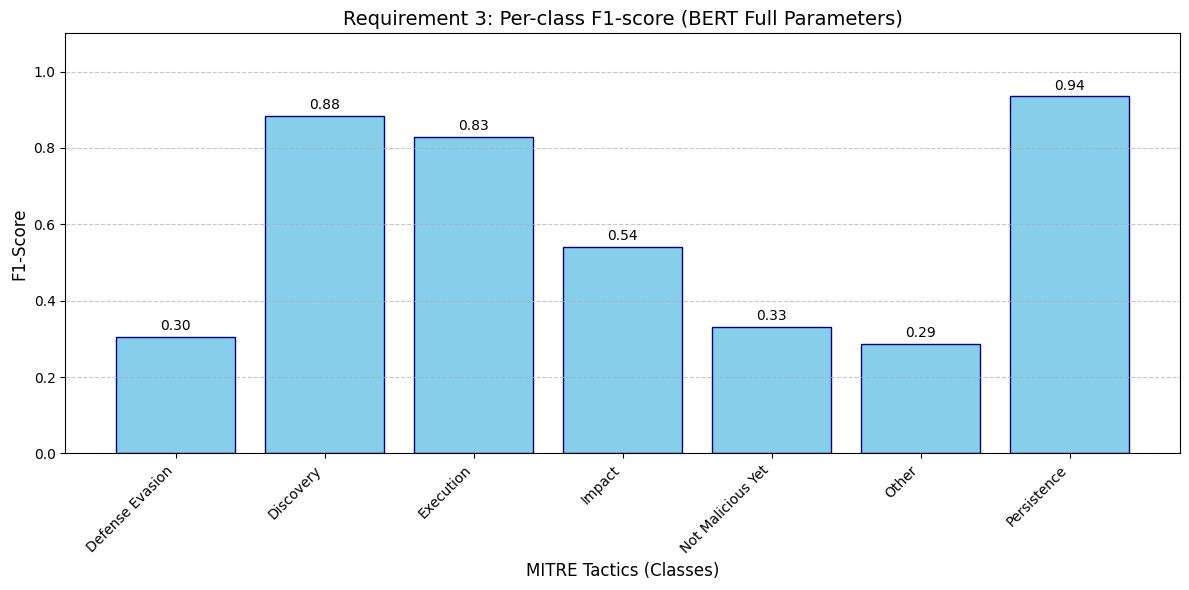

                REPORT GENERATION COMPLETE


In [30]:
pretrained_model = "google-bert/bert-base-uncased"
bert_full_parameters = AutoModelForTokenClassification.from_pretrained(
    pretrained_model_name_or_path=pretrained_model,
    id2label=id2label,
    label2id=label2id,
)

optimizer = AdamW(bert_full_parameters.parameters(), lr=LR) # Define optimizer

num_update_steps_per_epoch = len(train_dataloader) # Number of batches per epoch (total samples / batch size)
num_training_steps = N_TRAIN_EPOCHS * num_update_steps_per_epoch # Total number of training steps: number_batches_x_epoch x number of epochs!

lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

# Now we can call the training and evaluation function, which will return the best model, the best validation loss, the epoch at which it was found, and the training/validation losses for each epoch.
best_bert_full_parameters, best_val, best_epoch, train_losses, val_losses, metrics = train_and_evaluate(
    model=bert_full_parameters,
    train_dataloader=train_dataloader,
    eval_dataloader=eval_dataloader,
    optimizer=optimizer,
    lr_scheduler=lr_scheduler,
    N_TRAIN_EPOCHS=N_TRAIN_EPOCHS,
    postprocess=postprocess,
    compute_metrics=compute_metrics
)
print(f"Best validation loss: {best_val:.4f} at epoch {best_epoch + 1}")
plot_loss_curves(train_losses, val_losses)

final_test_metrics = evaluate_test_set(
    model=best_bert_full_parameters,
    test_dataloader=test_dataloader,
    postprocess_fn=postprocess,
    compute_metrics_fn=compute_metrics
)

display_all_metrics(final_test_metrics, report_name="BERT Full Parameters")

### Assume that this is a ‘simple problem’ (i.e., any model, refined with the same samples,could achieve the same scores). Therefore, create a baseline where instead of a pre-trained BERT (with its pre-trained weights), you load only the BERT architecture. Train this ‘naked’ BERT in an end-to-end manner.

100%|██████████| 390/390 [04:37<00:00,  1.41it/s]

Baseline Best validation loss: 0.4586 at epoch 16


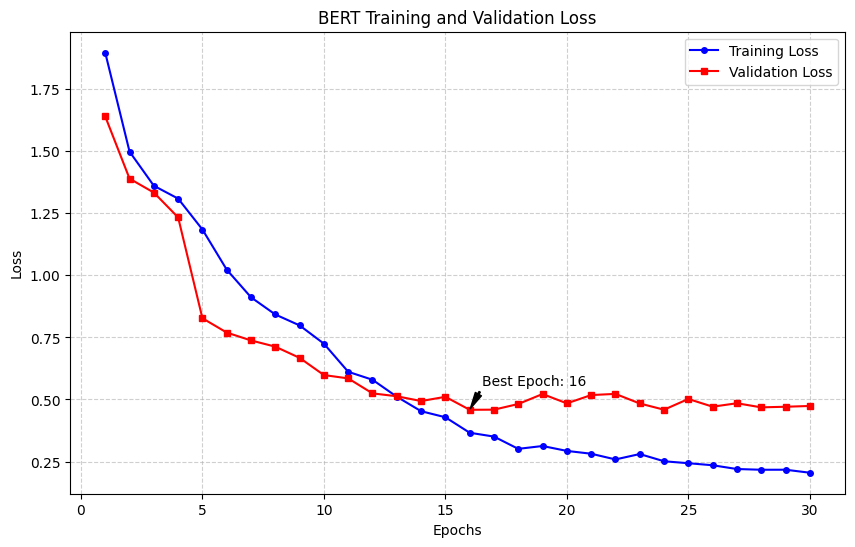

Starting final evaluation on test set...


Evaluating: 100%|██████████| 7/7 [00:01<00:00,  3.76it/s]



         BASELINE MODEL PERFORMANCE REPORT

           BERT BASELINE PERFORMANCE REPORT
[1] Global Token Accuracy:        0.7294
[2] Macro Average Metrics:
    - Precision: 0.5942 | Recall: 0.4473 | F1: 0.4699
[4] Average Session Fidelity:    0.7386

[5] Detailed Per-Class Metrics Table:
MITRE Tactic (Class)      | Accuracy   | Precision  | Recall     | F1-Score  
-----------------------------------------------------------------------------------------------
Defense Evasion           | 0.9785     | 0.5942     | 0.1126     | 0.1894    
Discovery                 | 0.8580     | 0.8742     | 0.8002     | 0.8356    
Execution                 | 0.8255     | 0.6603     | 0.7867     | 0.7180    
Impact                    | 0.9819     | 0.5872     | 0.2038     | 0.3026    
Not Malicious Yet         | 0.9162     | 0.2877     | 0.2805     | 0.2841    
Other                     | 0.9849     | 0.4730     | 0.1446     | 0.2215    
Persistence               | 0.9138     | 0.6828     | 0.8028     | 0

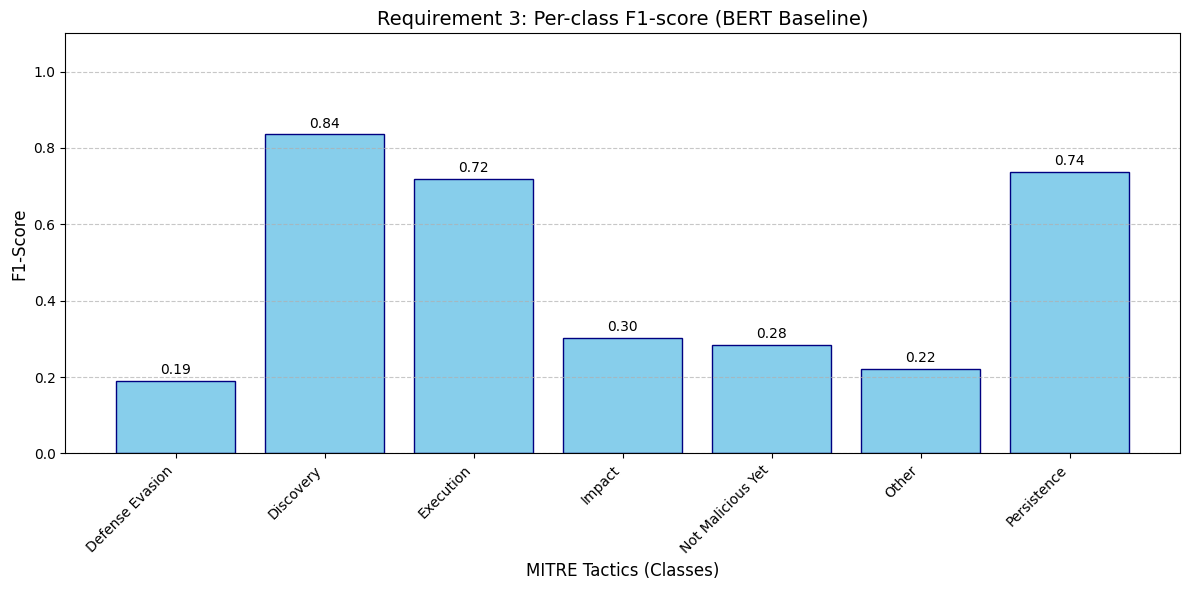

                REPORT GENERATION COMPLETE


In [31]:
from transformers import BertConfig, BertForTokenClassification

# 1. Load the pre-trained BERT configuration and modify it for our token classification task
config = BertConfig.from_pretrained(
    pretrained_model,
    id2label=id2label, 
    label2id=label2id
)

# 2. Initialize a new BERT model for token classification using the modified configuration
bert_baseline = BertForTokenClassification(config)

# 3. Define the optimizer for the baseline model
optimizer = AdamW(bert_baseline.parameters(), lr=LR)

# 4. Define the learning rate scheduler for the baseline model
baseline_lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

# 5. Train the baseline model using the same training and evaluation function
best_bert_baseline, baseline_best_val, baseline_best_epoch, baseline_train_losses, baseline_val_losses, baseline_metrics = train_and_evaluate(
    model=bert_baseline,
    train_dataloader=train_dataloader,
    eval_dataloader=eval_dataloader,
    optimizer=optimizer,
    lr_scheduler=baseline_lr_scheduler,
    N_TRAIN_EPOCHS=N_TRAIN_EPOCHS,
    postprocess=postprocess,
    compute_metrics=compute_metrics
)

print(f"Baseline Best validation loss: {baseline_best_val:.4f} at epoch {baseline_best_epoch + 1}")
plot_loss_curves(baseline_train_losses, baseline_val_losses)

# 6. Evaluate the baseline model on the test set
baseline_final_test_metrics = evaluate_test_set(
    model=best_bert_baseline,
    test_dataloader=test_dataloader,
    postprocess_fn=postprocess,
    compute_metrics_fn=compute_metrics
)
print("\n" + "="*50)
print("         BASELINE MODEL PERFORMANCE REPORT")
print("="*50)
display_all_metrics(baseline_final_test_metrics, report_name="BERT Baseline")

### Now fine-tune Unixcoder. Since Unixcoder was pre-trained with a coding corpus, the hypothesis is that it has more prior knowledge even on SSH (and therefore, it can obtain better results).

In [32]:
#create dataset for unixcoder
unixcoder_id = "microsoft/unixcoder-base"
unix_tokenizer = AutoTokenizer.from_pretrained(unixcoder_id, add_prefix_space=True)

unix_tokenized_datasets = encoded_dataset.map(
    tokenize_and_align_labels,
    batched=True,
    fn_kwargs={"tokenizer": unix_tokenizer}, # Pass the UniXcoder tokenizer to the mapping function
    remove_columns=original_columns
)
# Create DataLoaders for the UniXcoder tokenized datasets
unix_data_collator = DataCollatorForTokenClassification(tokenizer=unix_tokenizer)
unix_train_dataloader = DataLoader(
    unix_tokenized_datasets["train"],
    shuffle=True,
    collate_fn=unix_data_collator,
    batch_size=BATCH_SIZE,
)
unix_eval_dataloader = DataLoader(
    unix_tokenized_datasets["valid"], collate_fn=unix_data_collator, batch_size=BATCH_SIZE
)
unix_test_dataloader = DataLoader(
    unix_tokenized_datasets["test"], collate_fn=unix_data_collator, batch_size=BATCH_SIZE
)

Map: 100%|██████████| 108/108 [00:00<00:00, 2959.45 examples/s]


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4936.92it/s]
[transformers] RobertaForTokenClassification LOAD REPORT from: microsoft/unixcoder-base
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|██████████| 390/390 [04:11<00:00,  1.55it/s]

UniXcoder Best validation loss: 0.2907 at epoch 7


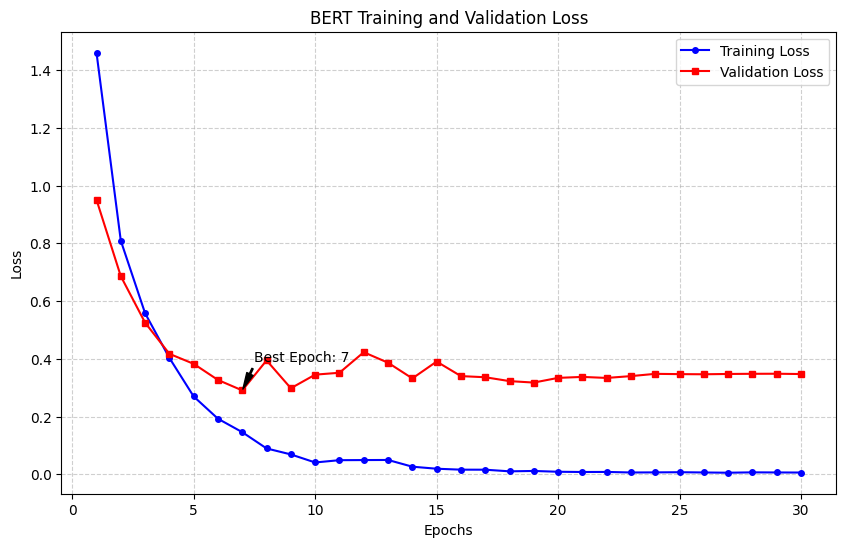

Starting final evaluation on test set...


Evaluating: 100%|██████████| 7/7 [00:01<00:00,  4.32it/s]



         UniXcoder Model Performance Report

           UNIXCODER FULL PARAMETERS PERFORMANCE REPORT
[1] Global Token Accuracy:        0.8608
[2] Macro Average Metrics:
    - Precision: 0.7933 | Recall: 0.6615 | F1: 0.6974
[4] Average Session Fidelity:    0.8388

[5] Detailed Per-Class Metrics Table:
MITRE Tactic (Class)      | Accuracy   | Precision  | Recall     | F1-Score  
-----------------------------------------------------------------------------------------------
Defense Evasion           | 0.9876     | 0.7631     | 0.7887     | 0.7757    
Discovery                 | 0.9184     | 0.9093     | 0.9057     | 0.9075    
Execution                 | 0.9148     | 0.8084     | 0.9304     | 0.8651    
Impact                    | 0.9873     | 0.8651     | 0.3993     | 0.5464    
Not Malicious Yet         | 0.9534     | 0.7531     | 0.2921     | 0.4210    
Other                     | 0.9867     | 0.5643     | 0.3816     | 0.4553    
Persistence               | 0.9733     | 0.8896     | 0

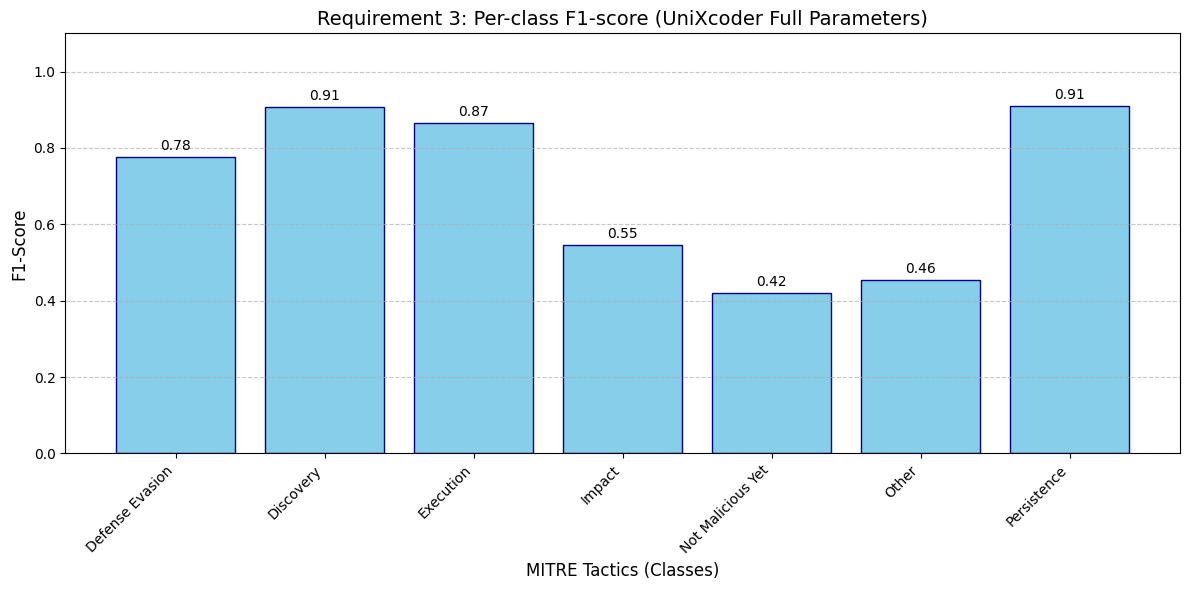

                REPORT GENERATION COMPLETE


In [33]:
# Now we can load the UniXcoder tokenizer and model for comparison
unixcoder_id = "microsoft/unixcoder-base"
from transformers import AutoModelForTokenClassification
# Load the UniXcoder model for token classification
unix_full_parameters = AutoModelForTokenClassification.from_pretrained(
    unixcoder_id,
    id2label=id2label,
    label2id=label2id,
)

optimizer = AdamW(unix_full_parameters.parameters(), lr=5e-5)

num_training_steps = N_TRAIN_EPOCHS * len(unix_train_dataloader)
unix_lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

# Train and evaluate the UniXcoder model using the same function, which will return the best model, validation loss, epoch, training/validation losses, and metrics.
best_unix_full_parameters, unix_val_loss, unix_epoch, unix_train_losses, unix_val_losses, unix_metrics = train_and_evaluate(
    model=unix_full_parameters,
    train_dataloader=unix_train_dataloader,
    eval_dataloader=unix_eval_dataloader,
    optimizer=optimizer,
    lr_scheduler=unix_lr_scheduler,
    N_TRAIN_EPOCHS=N_TRAIN_EPOCHS,
    postprocess=postprocess,
    compute_metrics=compute_metrics
)

print(f"UniXcoder Best validation loss: {unix_val_loss:.4f} at epoch {unix_epoch + 1}")
plot_loss_curves(unix_train_losses, unix_val_losses)

# Evaluate the best UniXcoder model on the test set
unix_final_test_metrics = evaluate_test_set(
    model=best_unix_full_parameters,
    test_dataloader=unix_test_dataloader,
    postprocess_fn=postprocess,
    compute_metrics_fn=compute_metrics
)
print("\n" + "="*50)
print("         UniXcoder Model Performance Report")
print("="*50)
display_all_metrics(unix_final_test_metrics, report_name="UniXcoder Full Parameters")


## Finally, perform an alternative fine-tuning of your best model. In particular, try fine-tuning:
– Only the last 2 encoding layers + classification head
– Only the classification head

## case 1:Only the last 2 encoding layers + classification head

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 9261.44it/s]
[transformers] RobertaForTokenClassification LOAD REPORT from: microsoft/unixcoder-base
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Full model has 125,344,519 parameters
Trainable parameters: 5,383
Trainable parameters: 14,181,127


100%|██████████| 390/390 [02:06<00:00,  3.07it/s]


UniXcoder Case 1 Best validation loss: 0.4490 at epoch 11


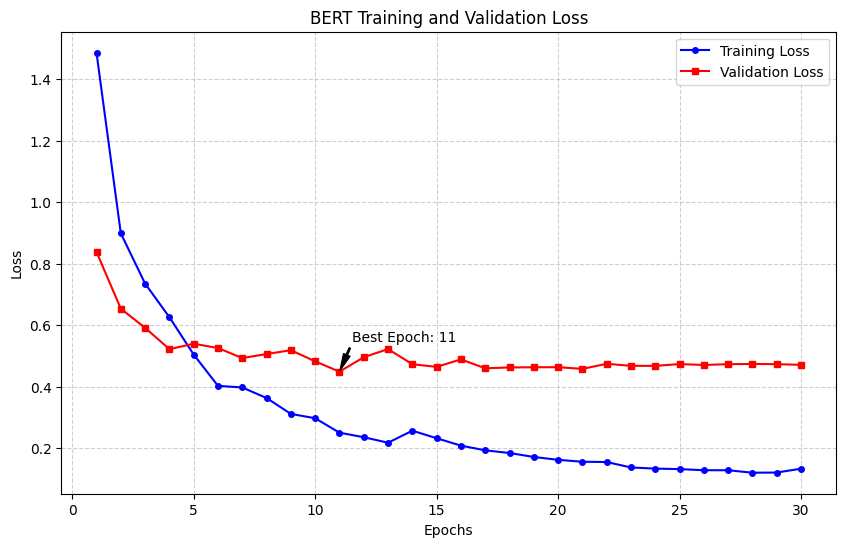

Starting final evaluation on test set...


Evaluating: 100%|██████████| 7/7 [00:01<00:00,  4.08it/s]



         UniXcoder Model Performance Report

           UNIXCODER LAST 2 LAYERS + CLASSIFIER PERFORMANCE REPORT
[1] Global Token Accuracy:        0.8341
[2] Macro Average Metrics:
    - Precision: 0.7306 | Recall: 0.5563 | F1: 0.5943
[4] Average Session Fidelity:    0.7966

[5] Detailed Per-Class Metrics Table:
MITRE Tactic (Class)      | Accuracy   | Precision  | Recall     | F1-Score  
-----------------------------------------------------------------------------------------------
Defense Evasion           | 0.9777     | 0.6636     | 0.3660     | 0.4718    
Discovery                 | 0.8967     | 0.8703     | 0.9005     | 0.8851    
Execution                 | 0.9119     | 0.7952     | 0.9428     | 0.8628    
Impact                    | 0.9833     | 0.7333     | 0.2015     | 0.3161    
Not Malicious Yet         | 0.9451     | 0.6048     | 0.1539     | 0.2454    
Other                     | 0.9870     | 0.5696     | 0.4348     | 0.4932    
Persistence               | 0.9664     | 0.8

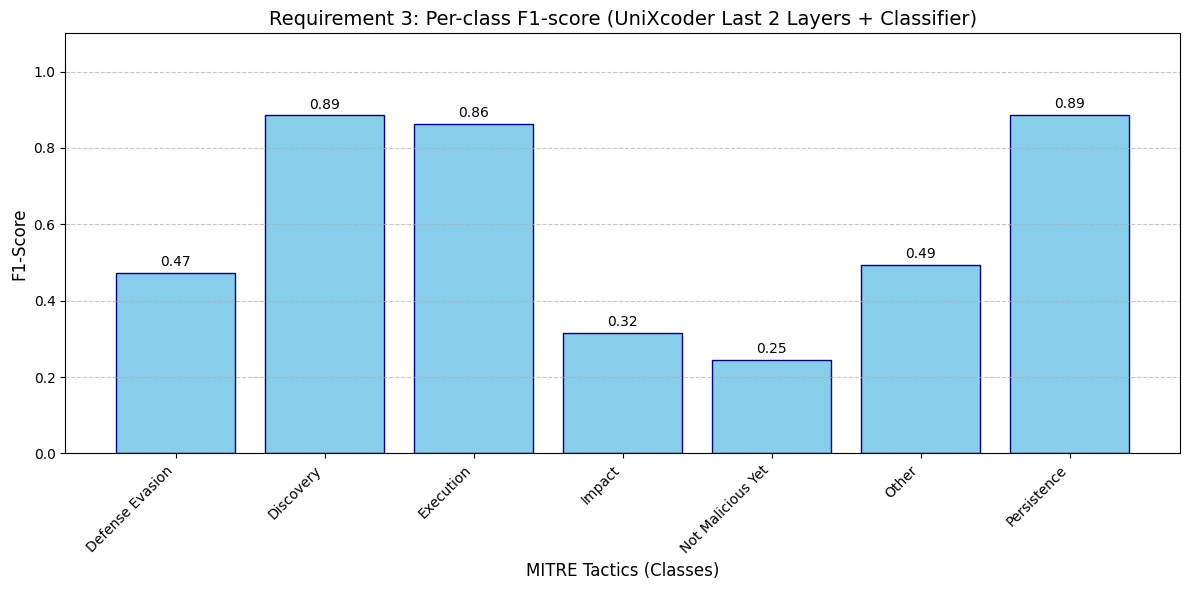

                REPORT GENERATION COMPLETE


In [37]:
#Only the last 2 encoding layers + classification head
pretrained_model = "microsoft/unixcoder-base"
from transformers import AutoModelForTokenClassification
unixcoder_case1 = AutoModelForTokenClassification.from_pretrained(
    pretrained_model_name_or_path=pretrained_model,
    id2label=id2label,
    label2id=label2id,
)

total_params = sum(p.numel() for p in unixcoder_case1.parameters())
print(f"Full model has {total_params:,} parameters")

# Freeze all layers
for param in unixcoder_case1.base_model.parameters():
    param.requires_grad = False

Freeze_trainable_params = sum(p.numel() for p in unixcoder_case1.parameters() if p.requires_grad)
print(f"Trainable parameters: {Freeze_trainable_params:,}")

# Unfreeze the last 2 layers
# The encoder part depends on the architecture. Let's assume it's BERT-like (most common).
for param in unixcoder_case1.base_model.encoder.layer[-2:].parameters():
    param.requires_grad = True

# The classification head (the token classifier) also needs to be trainable
for param in unixcoder_case1.classifier.parameters():
    param.requires_grad = True

Unfreeze_trainable_params = sum(p.numel() for p in unixcoder_case1.parameters() if p.requires_grad)
print(f"Trainable parameters: {Unfreeze_trainable_params:,}")

lr_encoder_last2 = 8e-5
optimizer = AdamW(
    filter(lambda p: p.requires_grad, unixcoder_case1.parameters()), 
    lr=lr_encoder_last2
)

num_training_steps = N_TRAIN_EPOCHS * len(unix_train_dataloader)
unix_lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

# Train and evaluate the UniXcoder model using the same function, which will return the best model, validation loss, epoch, training/validation losses, and metrics.
best_unix_model_case1, unix_val_loss, unix_epoch, unix_train_losses, unix_val_losses, unix_metrics = train_and_evaluate(
    model=unixcoder_case1,
    train_dataloader=unix_train_dataloader,
    eval_dataloader=unix_eval_dataloader,
    optimizer=optimizer,
    lr_scheduler=unix_lr_scheduler,
    N_TRAIN_EPOCHS=N_TRAIN_EPOCHS,
    postprocess=postprocess,
    compute_metrics=compute_metrics
)

print(f"UniXcoder Case 1 Best validation loss: {unix_val_loss:.4f} at epoch {unix_epoch + 1}")
plot_loss_curves(unix_train_losses, unix_val_losses)

# Evaluate the best UniXcoder model on the test set
unix_final_test_metrics = evaluate_test_set(
    model=best_unix_model_case1,
    test_dataloader=unix_test_dataloader,
    postprocess_fn=postprocess,
    compute_metrics_fn=compute_metrics
)
print("\n" + "="*50)
print("         UniXcoder Model Performance Report")
print("="*50)
display_all_metrics(unix_final_test_metrics, report_name="UniXcoder Last 2 Layers + Classifier")


## case2 Only the classification head

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7101.96it/s]
[transformers] RobertaForTokenClassification LOAD REPORT from: microsoft/unixcoder-base
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Full model has 125,344,519 parameters
Trainable parameters: 5,383
Trainable parameters: 5,383


100%|██████████| 390/390 [01:52<00:00,  3.47it/s]


UniXcoder Case 2 Best validation loss: 0.5976 at epoch 30


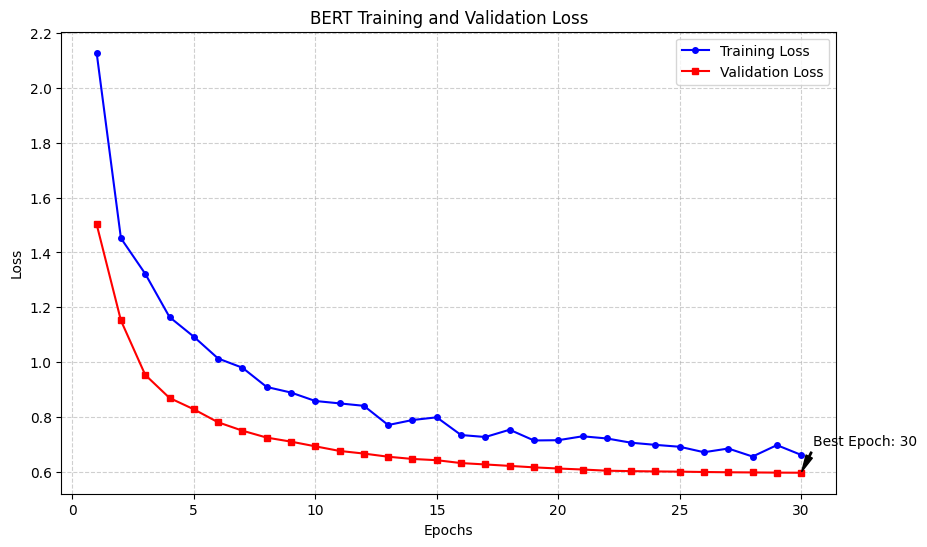

Starting final evaluation on test set...


Evaluating: 100%|██████████| 7/7 [00:01<00:00,  3.97it/s]



         UniXcoder Model Performance Report

           UNIXCODER ONLY CLASSIFIER PERFORMANCE REPORT
[1] Global Token Accuracy:        0.7239
[2] Macro Average Metrics:
    - Precision: 0.4885 | Recall: 0.3648 | F1: 0.3644
[4] Average Session Fidelity:    0.6662

[5] Detailed Per-Class Metrics Table:
MITRE Tactic (Class)      | Accuracy   | Precision  | Recall     | F1-Score  
-----------------------------------------------------------------------------------------------
Defense Evasion           | 0.9726     | 0.0000     | 0.0000     | 0.0000    
Discovery                 | 0.8339     | 0.7753     | 0.8785     | 0.8237    
Execution                 | 0.8212     | 0.6654     | 0.7871     | 0.7212    
Impact                    | 0.9808     | 0.4444     | 0.0147     | 0.0284    
Not Malicious Yet         | 0.9409     | 0.2927     | 0.0145     | 0.0277    
Other                     | 0.9858     | 0.5397     | 0.1643     | 0.2519    
Persistence               | 0.9126     | 0.7023     | 0

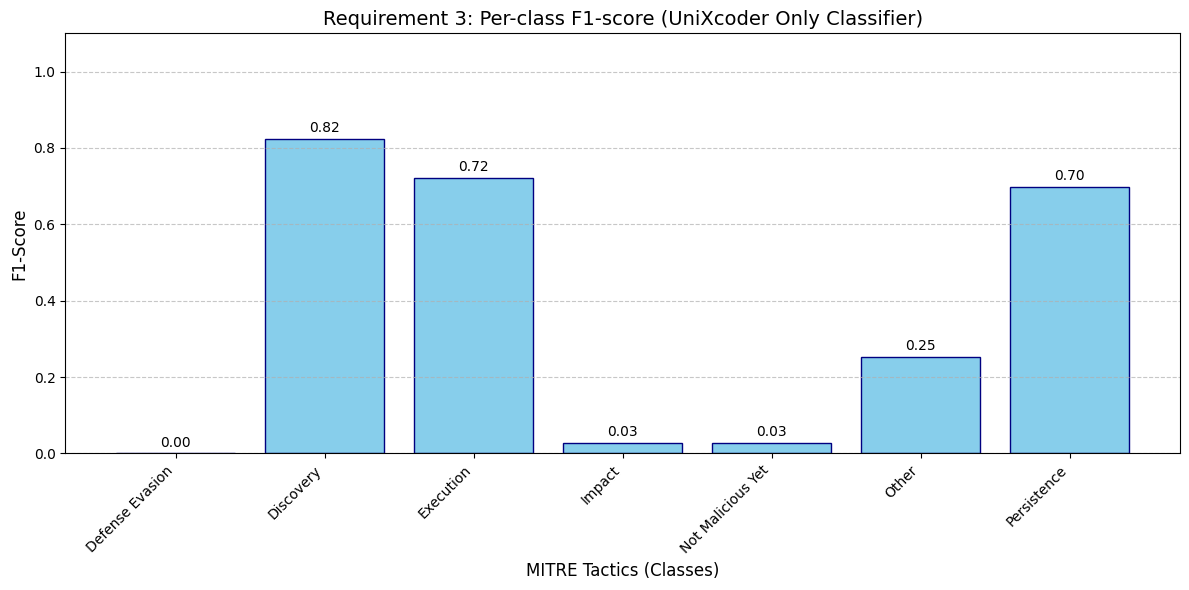

                REPORT GENERATION COMPLETE


In [41]:
#Only classification head
pretrained_model = "microsoft/unixcoder-base"
from transformers import AutoModelForTokenClassification
unixcoder_case2 = AutoModelForTokenClassification.from_pretrained(
    pretrained_model_name_or_path=pretrained_model,
    id2label=id2label,
    label2id=label2id,
)

total_params = sum(p.numel() for p in unixcoder_case2.parameters())
print(f"Full model has {total_params:,} parameters")

# Freeze all layers
for param in unixcoder_case2.base_model.parameters():
    param.requires_grad = False

Freeze_trainable_params = sum(p.numel() for p in unixcoder_case2.parameters() if p.requires_grad)
print(f"Trainable parameters: {Freeze_trainable_params:,}")

# The classification head (the token classifier) also needs to be trainable
for param in unixcoder_case2.classifier.parameters():
    param.requires_grad = True

Unfreeze_trainable_params = sum(p.numel() for p in unixcoder_case2.parameters() if p.requires_grad)
print(f"Trainable parameters: {Unfreeze_trainable_params:,}")

lr_classifier_head = 2e-4
optimizer = AdamW(
    filter(lambda p: p.requires_grad, unixcoder_case2.parameters()), 
    lr=lr_classifier_head
)

num_training_steps = N_TRAIN_EPOCHS * len(unix_train_dataloader)
unix_lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

# Train and evaluate the UniXcoder model using the same function, which will return the best model, validation loss, epoch, training/validation losses, and metrics.
best_unix_model_case2, unix_val_loss, unix_epoch, unix_train_losses, unix_val_losses, unix_metrics = train_and_evaluate(
    model=unixcoder_case2,
    train_dataloader=unix_train_dataloader,
    eval_dataloader=unix_eval_dataloader,
    optimizer=optimizer,
    lr_scheduler=unix_lr_scheduler,
    N_TRAIN_EPOCHS=N_TRAIN_EPOCHS,
    postprocess=postprocess,
    compute_metrics=compute_metrics
)  

print(f"UniXcoder Case 2 Best validation loss: {unix_val_loss:.4f} at epoch {unix_epoch + 1}")
plot_loss_curves(unix_train_losses, unix_val_losses)
# Evaluate the best UniXcoder model on the test set
unix_final_test_metrics = evaluate_test_set(
    model=best_unix_model_case2,
    test_dataloader=unix_test_dataloader,
    postprocess_fn=postprocess,
    compute_metrics_fn=compute_metrics
)
print("\n" + "="*50)
print("         UniXcoder Model Performance Report")
print("="*50)
display_all_metrics(unix_final_test_metrics, report_name="UniXcoder Only Classifier")


# Task 4: Inference

In [52]:
# load data from csv files
inference_df = pd.read_csv(f"{INPUT_PATH}/cyberlab.csv")
# Display the columns in the inference dataset to understand its structure
print("Columns in cyberlab.csv:")
print(inference_df.columns.tolist())
# Display the first row of the inference dataset
print("\nFirst row example:")
print(inference_df.iloc[0])

Columns in cyberlab.csv:
['session', 'timestamps_statements', 'country_name']

First row example:
session                  enable ; system ; shell ; sh ; cat /proc/mount...
timestamps_statements                     2019-09-01 00:00:10.493808+00:00
country_name                                                        Israel
Name: 0, dtype: object


In [53]:
# --- STEP 1: Pre-processing (Truncation and Date Extraction) ---
def truncate_words(text, max_len=30):
    """
    Truncates each word in the session to a maximum of 30 characters.
    """
    words = str(text).split()
    return " ".join([w[:max_len] for w in words])

# 1. Apply word truncation 
inference_df['processed_session'] = inference_df['session'].apply(truncate_words)

# 2. Extract date (YYYY-MM-DD) for grouping and plotting later [cite: 178]
inference_df['date'] = pd.to_datetime(inference_df['timestamps_statements']).dt.date

print("Example processed session:")
print(inference_df['processed_session'].iloc[0][:100], "...")
print(f"Extraction date: {inference_df['date'].iloc[0]}")

Example processed session:
enable ; system ; shell ; sh ; cat /proc/mounts; /bin/busybox TIPZU ; cd /dev/shm; cat .s || cp /bin ...
Extraction date: 2019-09-01


In [54]:
best_unix_full_parameters

RobertaForTokenClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(51416, 768, padding_idx=1)
      (token_type_embeddings): Embedding(10, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(1026, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
   

In [59]:
import torch
from tqdm import tqdm
import pandas as pd

def get_predictions_single_session(text, model, tokenizer):
    """
    Predicts MITRE tags for a single session using the 'First Token Rule'[cite: 159, 160].
    """
    # 1. Tokenization with 512 token limit [cite: 116]
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(model.device)
    word_ids = inputs.word_ids()
    
    # 2. Inference
    with torch.no_grad():
        logits = model(**inputs).logits
        preds = torch.argmax(logits, dim=-1).squeeze().tolist()
        
    # If single session returns a single pred (not a list), wrap it
    if isinstance(preds, int): preds = [preds]

    word_tags = []
    last_word_id = None
    
    # 3. Extract tag for the first token of each word [cite: 159, 160]
    for i, word_id in enumerate(word_ids):
        if word_id is not None and word_id != last_word_id:
            tag_name = id2label[preds[i]] # Using the mapping from Task 3
            word_tags.append(tag_name)
            last_word_id = word_id
            
    return word_tags

In [ ]:
model = best_unix_full_parameters
tokenizer = unix_tokenizer # Use the same tokenizer that was used for training the model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
# --- TASK 4: Execute Inference on dataset
# Apply the prediction function
# Note: Ensure id2label is defined from Task 3
tqdm.pandas() # Enable progress bar for pandas
# Execute Batch Inference
inference_df['fingerprint'] = inference_df['processed_session'].progress_apply(
    lambda x: get_predictions_single_session(x, model, tokenizer)
)
# --- SAVE RESULTS ---
# Save as CSV. Note: fingerprints will be saved as string representations of lists.
output_csv = "cyberlab_inference_results.csv"
inference_df.to_csv(output_csv, index=False)
print(f"Success! Inference completed for {len(inference_df)} sessions.")
print(f"Results saved to: {output_csv}")

100%|██████████| 174262/174262 [1:09:09<00:00, 42.00it/s] 


Success! Inference completed for 174262 sessions.
Results saved to: cyberlab_inference_results.csv


In [2]:
import pandas as pd
import ast
from collections import Counter

# 1. Configuration
file_path = 'cyberlab_inference_results.csv'
target_cmds = ['cat', 'grep', 'echo', 'rm']
chunk_size = 10000  # Process 10,000 sessions at a time

# Data structures to store results across chunks
global_counts = [] # To store command-tag pairs for final frequency table
unique_examples = {} # Dictionary to store one example session per (command, tag) tuple

print(f"Starting batch processing in chunks of {chunk_size}...")

# 2. Iterate through the CSV in chunks
# This prevents loading the entire 800MB file into RAM at once
reader = pd.read_csv(file_path, usecols=['session', 'processed_session', 'fingerprint'], chunksize=chunk_size)

for i, chunk in enumerate(reader):
    print(f"Processing chunk {i+1}...")
    
    # Safely convert string fingerprints to Python lists
    chunk['fingerprint'] = chunk['fingerprint'].apply(ast.literal_eval)
    
    for _, row in chunk.iterrows():
        words = str(row['processed_session']).split()
        tags = row['fingerprint']
        
        # Align words and tags
        for w, t in zip(words, tags):
            if w in target_cmds:
                # Store for frequency calculation
                global_counts.append((w, t))
                
                # Capture a qualitative example if we haven't seen this (command, tag) pair yet
                pair_key = (w, t)
                if pair_key not in unique_examples:
                    unique_examples[pair_key] = row['session']

# 3. Post-processing: Generate Frequency Table
analysis_df = pd.DataFrame(global_counts, columns=['command', 'predicted_tag'])
final_freq_table = pd.crosstab(analysis_df['command'], analysis_df['predicted_tag'])

print("\n" + "="*30)
print("FINAL FREQUENCY TABLE")
print("="*30)
print(final_freq_table)

# 4. Post-processing: Output Qualitative Examples
print("\n" + "="*30)
print("QUALITATIVE ANALYSIS EXAMPLES")
print("="*30)

for (cmd, tag), session in unique_examples.items():
    print(f"\nTUPLE: ({cmd}, {tag})")
    print(f"Context: {session[:350]}...") # Print first 350 chars for the report
    print("-" * 40)

# Optional: Save the table to a small CSV for your report
final_freq_table.to_csv('task4_command_stats.csv')

Starting batch processing in chunks of 10000...
Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...

FINAL FREQUENCY TABLE
predicted_tag  Defense Evasion  Discovery  Execution  Impact  \
command                                                        
cat                          9     530029       8746       2   
echo                        14     609073       4681       0   
grep                      3769     769326       5446       0   
rm                          29     173792      15661       0   

predicted_tag  Not Malicious Yet  Other  Persistence  
command                                               
cat                          

Step 1: Loading data and parsing fingerprint strings...
  Processing batch 1...
  Processing batch 2...
  Processing batch 3...
  Processing batch 4...
  Data merged successfully.
Step 2: Identifying unique fingerprints and assigning 'Birth' IDs...
  Mapping IDs to sessions (Bypassing Pandas index alignment)...
Step 3: Aggregating daily counts and rendering Figure 2...


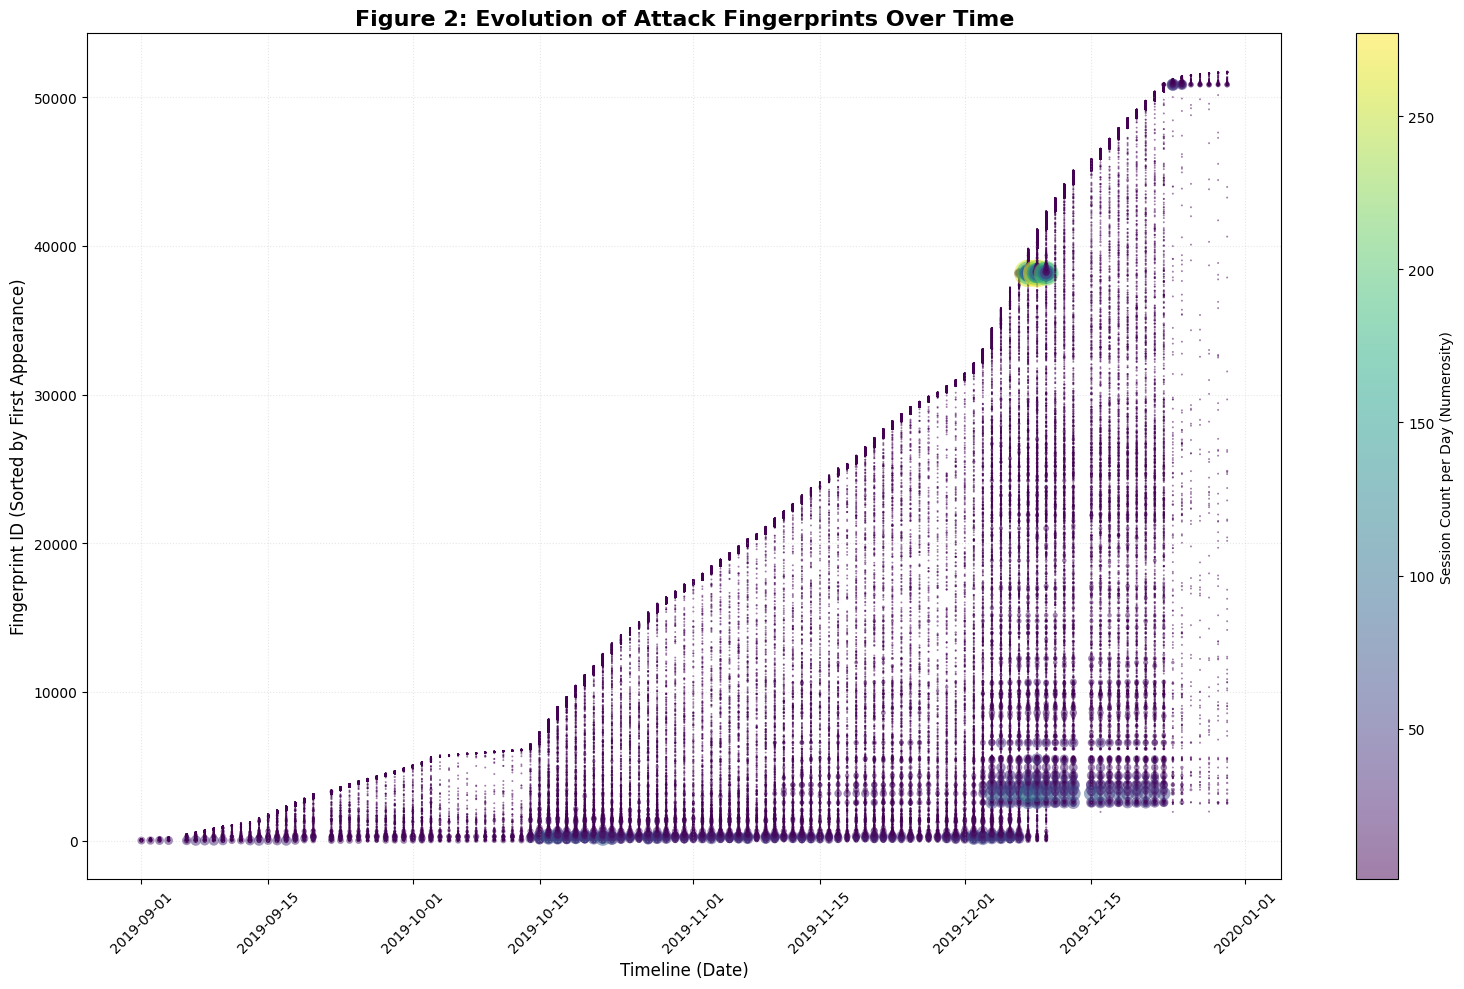


Task Complete! Your PDF is saved as: Fingerprint_Evolution_Final_v3.pdf


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np

# ============================================================
# 1. FAST LOADING & STRING PARSING
# ============================================================
file_path = 'cyberlab_inference_results.csv'
chunk_size = 50000 
chunks = []

print("Step 1: Loading data and parsing fingerprint strings...")

# Loading only required columns to keep memory usage low
reader = pd.read_csv(file_path, usecols=['timestamps_statements', 'fingerprint'], chunksize=chunk_size)

for i, chunk in enumerate(reader):
    print(f"  Processing batch {i+1}...")
    
    # PERFORMANCE FIX: Manually parse the list-string into a tuple.
    # This avoids the overhead of ast.literal_eval.
    chunk['fp_tuple'] = chunk['fingerprint'].str.strip("[]")\
                                           .str.replace("'", "", regex=False)\
                                           .str.replace('"', "", regex=False)\
                                           .str.split(", ")\
                                           .apply(tuple)
    
    # Convert timestamp string to datetime objects
    chunk['timestamp'] = pd.to_datetime(chunk['timestamps_statements'])
    chunks.append(chunk[['timestamp', 'fp_tuple']])

# Merge all chunks into a single DataFrame
inference_df = pd.concat(chunks, ignore_index=True)
del chunks # Clear memory immediately
print("  Data merged successfully.")

# ============================================================
# 2. CHRONOLOGICAL FINGERPRINT ID ASSIGNMENT
# ============================================================
print("Step 2: Identifying unique fingerprints and assigning 'Birth' IDs...")

# 1. Group by unique fingerprints to find the earliest appearance (Date of Birth)
fp_dob = inference_df.groupby('fp_tuple')['timestamp'].min().reset_index()

# 2. Sort fingerprints chronologically: Earliest patterns get the lowest IDs
fp_dob = fp_dob.sort_values('timestamp').reset_index(drop=True)
fp_dob['fp_id'] = fp_dob.index

# 3. Create a dictionary for O(1) constant-time lookup
id_mapping = dict(zip(fp_dob['fp_tuple'], fp_dob['fp_id']))

# 4. CRITICAL FIX: Bypass Pandas Indexing to avoid InvalidIndexError
# Using list comprehension for assignment avoids index alignment checks
print("  Mapping IDs to sessions (Bypassing Pandas index alignment)...")
inference_df['fp_id'] = [id_mapping.get(fp) for fp in inference_df['fp_tuple']]

# ============================================================
# 3. STATISTICAL AGGREGATION & FIGURE 2 PLOTTING
# ============================================================
print("Step 3: Aggregating daily counts and rendering Figure 2...")

# Extract only the date for daily frequency analysis
inference_df['date'] = inference_df['timestamp'].dt.date
daily_counts = inference_df.groupby(['date', 'fp_id']).size().reset_index(name='numerosity')

output_file = 'Fingerprint_Evolution_Final_v3.pdf'
with PdfPages(output_file) as pdf:
    plt.figure(figsize=(16, 10))
    
    # Plotting Figure 2:
    # x: Timeline (Date), y: Fingerprint ID (Birth order)
    # s: Point size (Numerosity) - np.clip keeps the dots from being too large
    # c: Color based on session count frequency
    scatter = plt.scatter(
        x=daily_counts['date'],
        y=daily_counts['fp_id'],
        s=np.clip(daily_counts['numerosity'] * 1.5, 2, 800), 
        c=daily_counts['numerosity'],
        cmap='viridis',
        alpha=0.5,
        edgecolors='none'
    )
    
    # Apply scientific formatting and labels
    plt.colorbar(scatter, label='Session Count per Day (Numerosity)')
    plt.xlabel('Timeline (Date)', fontsize=12)
    plt.ylabel('Fingerprint ID (Sorted by First Appearance)', fontsize=12)
    plt.title('Figure 2: Evolution of Attack Fingerprints Over Time', fontsize=16, fontweight='bold')
    
    plt.xticks(rotation=45)
    plt.grid(True, which='both', linestyle=':', alpha=0.3)
    plt.tight_layout()
    
    # Save current figure to the PDF file
    pdf.savefig()
    plt.show()

print(f"\nTask Complete! Your PDF is saved as: {output_file}")